### 3차 실험(프로젝트) 요약 및 회고
#### 실험 요약
- 본 프로젝트는 RNN으로 LSTM을 이용하여 Seq2Seq를 구현하였으며 한국어를 영어로 번역하는 번역기 개발을 목적으로 함
- 토큰화는 SentencePiece(BPE)을 Seq2Seq 모델은 3종(바닐라모델 및 2개의 Attention 모델)를 설계 및 학습하고 평가하였음.
- 이번에는 dev 데이터셋을 Validation에 활용함
- 학습 초기에 validation loss가 불안정하여 조기종료되는 것을 막기 위해 Two Track으로 학습, TracK A에는 WARMUP_EPOCHS 도입.
- WARMUP_EPOCHS 동안: Val은 TF=1.0로만 측정하되, best/earlystop/scheduler 카운트 금지
- 이후(=epoch WARMUP+1부터): Val은 TF=0.0로 측정, 그때부터 best/earlystop/scheduler 시작
- Track-B free-run subset은 그대로(정성 모니터링)

#### 3차 실험 회고
- 이번 실험은 2차 시험에서 발견된 미진한 부분을 정리하였음
- 이번에는 Luong Attention이 약간 개선되기는 하였지만, 전반적 2차 실험보다 성능이 오히려 떨어졌음
- 실험 결과는 앞에서와 같이 Bahdanau가 가장 안정적, Luong, Vanilla 순으로 성능을 보임
  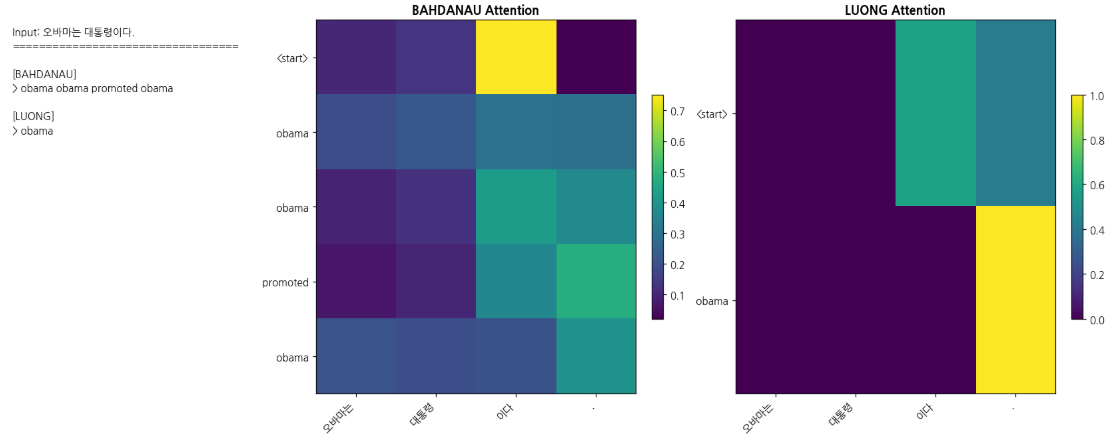

### Task 확인 및 프로젝트 방향
---
#### Task 확인 : Seq2Seq으로 한-영 번역기 만들기(입력: 한국어, 출력: 영어)
---
### Project Process
---
#### step 1 데이터 다운로드 
- 데이터 다운로드 및 구조 확인(train/dev/test)
- Train: 학습에만 사용
- dev는 validation으로 사용
- Test: 최종 평가에만 사용
#### step 2 데이터 정제
- exp 2와 같은 조건
#### step 3 데이터 토큰화
- exp2와 같은 조건
#### step 4 모델설계
- 데이터파이프라인, train 데이터는 train으로만 사용, dev데이터는 validation 으로 사용
- RNN은 LSTM 사용
- Vanilla Seq2Seq
- Bahdanau Attention Seq2Seq
- Luong Attention Seq2Seq
#### step 5 모델학습:
- 조기종료를 늦추기 위해 exp 2의 조건(Two Track 전략 + Worm-up) 유지
#### Step 6 모델평가
- 러닝커브, 어텐션 맵 구현
- test dataset 전체에 대해 Corpus BLEU
- 보조 지표로 BLEU + chrF
- 3개 모델 성능 비교 및 에러 분석(짧은 문장/고유명사/부정문 등)
---

### Step 1 라이브러리 블러오기 및 데이터 다운로드
- 필요 라이이브러리 import 및 버전확인
- 데이터 다운로드 및 구조 확인(train/dev/test)
- Train: 학습에만 사용,  train dataset를 train/validation으로 나누지 않는다는 가이드라인에 따름
- Dev: Validation (하이퍼파라미터/early stopping/모델 선택에 사용)
- Test: 최종 평가에만 사용

In [7]:
# ============================================================
# [STEP 0-CELL 0] GPU 캐시 초기화 및 환경 설정
# ============================================================
import torch
import gc
import os

# 1. GPU 캐시 및 메모리 비우기
def clear_gpu_cache():
    # Python 가비지 컬렉션 강제 실행
    gc.collect()
    # PyTorch의 CUDA 캐시 비우기
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        print(f"[OK] GPU 캐시가 비워졌습니다. (현재 사용 중: {torch.cuda.memory_allocated() / 1024**2:.2f} MB)")
    else:
        print("[Info] CUDA를 사용할 수 없는 환경입니다.")

clear_gpu_cache()

# 2. 결과 저장 경로 초기화 (필요 시)
SAVE_DIR = "s2s_translation/checkpoints"
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

[OK] GPU 캐시가 비워졌습니다. (현재 사용 중: 0.00 MB)


In [9]:
# ============================================================
# [STEP 1-CELL 1] 환경 설정 및 재현성 고정
# ============================================================

import os
import re
import urllib.request
import tarfile
import random
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. Device & Version
print(f"torch: {torch.__version__} | device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
seed_everything(42)

# 3. Matplotlib Font (Windows NanumGothic)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
font_path = r"C:\Windows\Fonts\NanumGothic.ttf"
if os.path.exists(font_path):
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams["font.family"] = font_name
    plt.rcParams["axes.unicode_minus"] = False
    print(f"Font set: {font_name}")
else:
    print("Warning: NanumGothic font not found.")

torch: 2.8.0+cu126 | device: cuda
Font set: NanumGothic


In [11]:
# ============================================================
# [STEP 1-CELL 2] 경로 정의 및 데이터 다운로드/압축해제  (✅ dev 추가)
# - 이번 실험 가이드라인:
#   * Train: 학습에만 사용 (train을 train/val로 쪼개지 않음)
#   * Dev  : Validation (하이퍼파라미터/early stopping/모델 선택)
#   * Test : 최종 평가 전용
# ============================================================

# 1. Path Configuration
project_root = Path("s2s_translation").resolve()
dataset_root = project_root / "datasets" / "ko_en_news_v1"
dl_dir, raw_dir = dataset_root / "downloads", dataset_root / "raw"
for p in [dl_dir, raw_dir]:
    p.mkdir(parents=True, exist_ok=True)

# 2. Download & Extract Utils
def download_and_extract(url, split):
    tar_path = dl_dir / f"korean-english-park.{split}.tar.gz"
    extract_path = raw_dir / f"{split}_raw"

    # Download
    if not tar_path.exists():
        print(f"[DOWN] {split} dataset...")
        urllib.request.urlretrieve(url, str(tar_path))

    # Extract
    if not any(extract_path.iterdir() if extract_path.exists() else []):
        extract_path.mkdir(parents=True, exist_ok=True)
        print(f"[EXTR] {split} dataset...")
        with tarfile.open(tar_path, "r:gz") as tar:
            tar.extractall(path=extract_path)

    return extract_path

# ✅ dev 추가
urls = {
    "train": "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz",
    "dev":   "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.dev.tar.gz",
    "test":  "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.test.tar.gz",
}

split_raw_dirs = {split: download_and_extract(url, split) for split, url in urls.items()}
print(f"[OK] Project Root: {project_root}")


[OK] Project Root: D:\PyProject\AIFFEL_AI\LLM\s2s_translation


In [13]:
# ============================================================
# [STEP 1-CELL 3] 데이터 로드 (Parallel DataFrame)  (✅ dev 로드)
# ============================================================
def load_parallel_df(split_dir, split_name):
    files = list(split_dir.rglob(f"*{split_name}*"))

    ko_candidates = sorted([p for p in files if p.suffix == ".ko"])
    en_candidates = sorted([p for p in files if p.suffix == ".en"])

    if len(ko_candidates) == 0 or len(en_candidates) == 0:
        raise FileNotFoundError(
            f"[{split_name}] .ko/.en 파일을 찾지 못했습니다.\n"
            f"- split_dir={split_dir}\n"
            f"- found_ko={len(ko_candidates)}, found_en={len(en_candidates)}\n"
            f"- hint: 압축 해제 구조/파일명을 확인하세요."
        )

    # 기존 로직 최대 유지: 정렬 후 첫 번째 사용
    ko_path = ko_candidates[0]
    en_path = en_candidates[0]

    with open(ko_path, "r", encoding="utf-8") as f:
        kor = [l.strip() for l in f]
    with open(en_path, "r", encoding="utf-8") as f:
        eng = [l.strip() for l in f]

    if len(kor) != len(eng):
        print(f"[WARN] [{split_name}] ko/en 라인 수가 다릅니다: ko={len(kor)}, en={len(eng)} (min 길이로 자릅니다)")
        m = min(len(kor), len(eng))
        kor, eng = kor[:m], eng[:m]

    df = pd.DataFrame({"kor": kor, "eng": eng})
    print(f"[{split_name.upper()}] Loaded: {len(df):,} pairs")
    return df

train_df = load_parallel_df(split_raw_dirs["train"], "train")
dev_df   = load_parallel_df(split_raw_dirs["dev"],   "dev")
test_df  = load_parallel_df(split_raw_dirs["test"],  "test")

# ✅ 이번 실험 규칙 고정: dev를 validation으로 사용
val_df = dev_df
print(f"[OK] Split fixed | train={len(train_df):,} | val(dev)={len(val_df):,} | test={len(test_df):,}")
print("[RULE] Train split은 train/val로 재분할하지 않습니다. (dev를 validation으로 사용)")

[TRAIN] Loaded: 94,123 pairs
[DEV] Loaded: 1,000 pairs
[TEST] Loaded: 2,000 pairs
[OK] Split fixed | train=94,123 | val(dev)=1,000 | test=2,000
[RULE] Train split은 train/val로 재분할하지 않습니다. (dev를 validation으로 사용)


In [15]:
# ============================================================
# [STEP 1-CELL 4] 정교한 데이터 통계 및 리포트 (통합 버전)  (✅ dev 포함)
# ============================================================
def summarize_split(df, name="train"):
    # 1. 기본 메트릭 계산
    n = len(df)
    kor_char = df["kor"].astype(str).str.len()
    eng_char = df["eng"].astype(str).str.len()
    kor_tok  = df["kor"].astype(str).str.split().str.len()
    eng_tok  = df["eng"].astype(str).str.split().str.len()

    dup = df.duplicated(subset=["kor", "eng"]).sum()

    # 한글 비율 계산 (분모 0 방지)
    total_kor_len = kor_char.sum()
    kor_hangul_ratio = df["kor"].astype(str).str.count(r"[가-힣]").sum() / max(1, total_kor_len)

    total_eng_len = eng_char.sum()
    eng_hangul_ratio = df["eng"].astype(str).str.count(r"[가-힣]").sum() / max(1, total_eng_len)

    summary = {
        "name": name,
        "n": n,
        "dup_pairs": int(dup),
        "dup_ratio": float(dup / max(1, n)),
        # Character Stats
        "kor_char_min": float(kor_char.min()), "kor_char_med": float(kor_char.median()),
        "kor_char_mean": float(kor_char.mean()), "kor_char_max": float(kor_char.max()),
        "eng_char_min": float(eng_char.min()), "eng_char_med": float(eng_char.median()),
        "eng_char_mean": float(eng_char.mean()), "eng_char_max": float(eng_char.max()),
        # Token Stats (whitespace based)
        "kor_tok_min": float(kor_tok.min()), "kor_tok_med": float(kor_tok.median()),
        "kor_tok_mean": float(kor_tok.mean()), "kor_tok_max": float(kor_tok.max()),
        "eng_tok_min": float(eng_tok.min()), "eng_tok_med": float(eng_tok.median()),
        "eng_tok_mean": float(eng_tok.mean()), "eng_tok_max": float(eng_tok.max()),
        # Language Ratio
        "kor_hangul_ratio": float(kor_hangul_ratio),
        "eng_hangul_ratio": float(eng_hangul_ratio),
        # 원본 시리즈 보존 (시각화용)
        "kor_tok_series": kor_tok,
        "eng_tok_series": eng_tok,
        "kor_char_series": kor_char,
        "eng_char_series": eng_char,
    }

    # 2. 콘솔 출력
    print("\n" + "=" * 20 + f" {name.upper()} SUMMARY " + "=" * 20)
    print(f"Total sentence pairs: {n:,}")
    print(f"Duplicate pairs     : {dup:,} ({summary['dup_ratio'] * 100:.2f}%)")
    print(f"Hangul ratio        | Kor: {kor_hangul_ratio:.4f} | Eng: {eng_hangul_ratio:.4f}")
    print(f"Kor token len (ws)  : min={summary['kor_tok_min']:.0f}, med={summary['kor_tok_med']:.0f}, mean={summary['kor_tok_mean']:.1f}, max={summary['kor_tok_max']:.0f}")
    print(f"Eng token len (ws)  : min={summary['eng_tok_min']:.0f}, med={summary['eng_tok_med']:.0f}, mean={summary['eng_tok_mean']:.1f}, max={summary['eng_tok_max']:.0f}")
    print(f"Kor char len        : min={summary['kor_char_min']:.0f}, med={summary['kor_char_med']:.0f}, mean={summary['kor_char_mean']:.1f}, max={summary['kor_char_max']:.0f}")
    print(f"Eng char len        : min={summary['eng_char_min']:.0f}, med={summary['eng_char_med']:.0f}, mean={summary['eng_char_mean']:.1f}, max={summary['eng_char_max']:.0f}")

    return summary

# 통계 실행 및 저장 (✅ dev 포함)
pre_stats = {
    "train": summarize_split(train_df, "train"),
    "dev":   summarize_split(dev_df,   "dev"),
    "test":  summarize_split(test_df,  "test"),
}


==================== TRAIN SUMMARY ====================
Total sentence pairs: 94,123
Duplicate pairs     : 15,182 (16.13%)
Hangul ratio        | Kor: 0.6846 | Eng: 0.0000
Kor token len (ws)  : min=1, med=14, mean=14.0, max=82
Eng token len (ws)  : min=1, med=20, mean=20.9, max=90
Kor char len        : min=1, med=59, mean=60.8, max=377
Eng char len        : min=1, med=121, mean=126.1, max=605

==================== DEV SUMMARY ====================
Total sentence pairs: 1,000
Duplicate pairs     : 0 (0.00%)
Hangul ratio        | Kor: 0.6906 | Eng: 0.0000
Kor token len (ws)  : min=1, med=15, mean=15.1, max=44
Eng token len (ws)  : min=1, med=21, mean=22.1, max=64
Kor char len        : min=4, med=64, mean=66.1, max=183
Eng char len        : min=11, med=126, mean=133.6, max=416

==================== TEST SUMMARY ====================
Total sentence pairs: 2,000
Duplicate pairs     : 4 (0.20%)
Hangul ratio        | Kor: 0.6904 | Eng: 0.0000
Kor token len (ws)  : min=1, med=15, mean=15.4, max=

[train_ko] 95% of sentences are under length: 26.0
[dev_ko] 95% of sentences are under length: 26.0
[test_ko] 95% of sentences are under length: 27.0
[train_en] 95% of sentences are under length: 39.0
[dev_en] 95% of sentences are under length: 39.0
[test_en] 95% of sentences are under length: 40.0


C:\Users\hugctx\AppData\Local\Temp\ipykernel_43464\823133190.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(


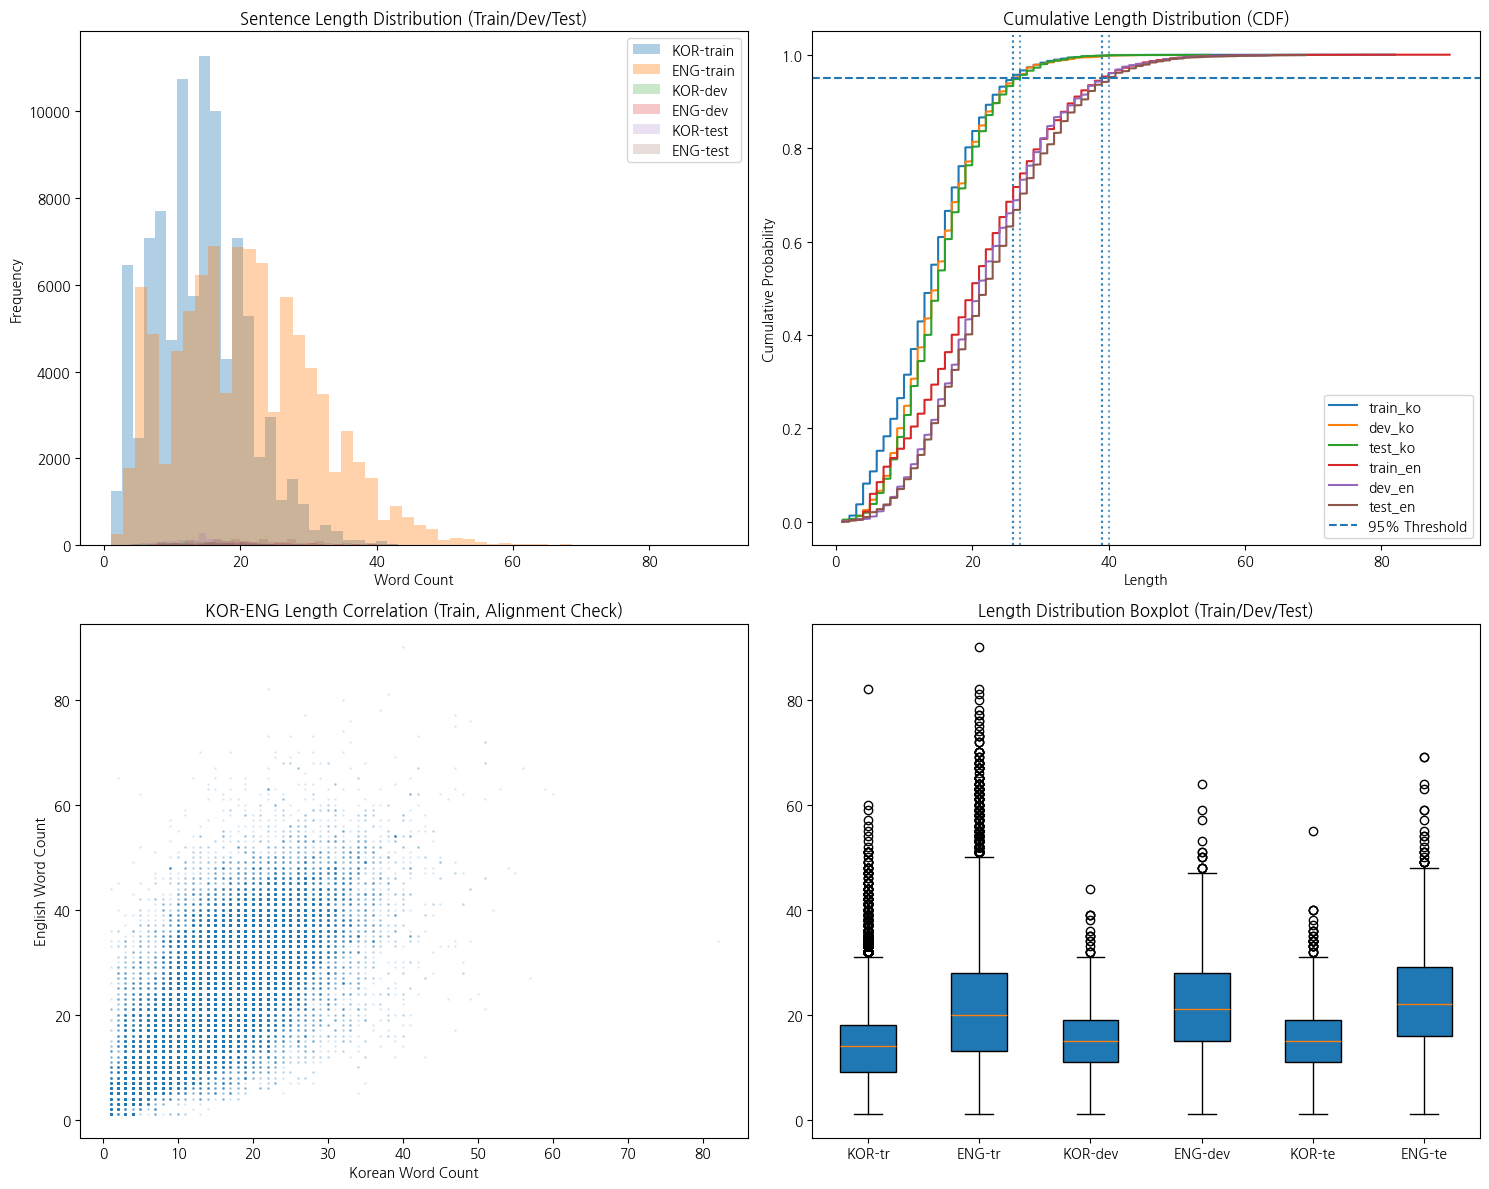

In [17]:
# ============================================================
# [STEP 1-CELL 5] 시각화 (업그레이드 버전)  (✅ train/dev/test 비교)
# - 기존 구조 최대 유지:
#   * 기존 2x2 레이아웃은 유지하되, 데이터는 train 기준 + dev/test 비교를 추가
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def ensure_len_cols(df):
    # 0. 데이터프레임에 길이 정보가 없을 경우를 대비해 자동 생성
    if 'ko_len' not in df.columns:
        df['ko_len'] = df['kor'].astype(str).apply(lambda x: len(x.split()))
    if 'en_len' not in df.columns:
        df['en_len'] = df['eng'].astype(str).apply(lambda x: len(x.split()))
    return df

train_df = ensure_len_cols(train_df)
dev_df   = ensure_len_cols(dev_df)
test_df  = ensure_len_cols(test_df)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 히스토그램 (어절 기준 분포) - ✅ train/dev/test 오버레이
axes[0, 0].hist(train_df['ko_len'], bins=50, alpha=0.35, label='KOR-train')
axes[0, 0].hist(train_df['en_len'], bins=50, alpha=0.35, label='ENG-train')

axes[0, 0].hist(dev_df['ko_len'],   bins=50, alpha=0.25, label='KOR-dev')
axes[0, 0].hist(dev_df['en_len'],   bins=50, alpha=0.25, label='ENG-dev')

axes[0, 0].hist(test_df['ko_len'],  bins=50, alpha=0.20, label='KOR-test')
axes[0, 0].hist(test_df['en_len'],  bins=50, alpha=0.20, label='ENG-test')

axes[0, 0].set_title("Sentence Length Distribution (Train/Dev/Test)")
axes[0, 0].set_xlabel("Word Count")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend()

# 2. 누적분포도 (CDF) - ✅ train/dev/test + P95 표시
def plot_cdf(ax, data, label):
    sorted_data = np.sort(data)
    yvals = np.arange(len(sorted_data)) / float(len(sorted_data))
    ax.plot(sorted_data, yvals, label=label)
    p95_val = np.percentile(sorted_data, 95)
    ax.axvline(x=p95_val, linestyle=':', alpha=0.7)
    print(f"[{label}] 95% of sentences are under length: {p95_val:.1f}")

# ko_len CDF
plot_cdf(axes[0, 1], train_df['ko_len'].values, "train_ko")
plot_cdf(axes[0, 1], dev_df['ko_len'].values,   "dev_ko")
plot_cdf(axes[0, 1], test_df['ko_len'].values,  "test_ko")

# en_len CDF
plot_cdf(axes[0, 1], train_df['en_len'].values, "train_en")
plot_cdf(axes[0, 1], dev_df['en_len'].values,   "dev_en")
plot_cdf(axes[0, 1], test_df['en_len'].values,  "test_en")

axes[0, 1].axhline(y=0.95, linestyle='--', label='95% Threshold')
axes[0, 1].set_title("Cumulative Length Distribution (CDF)")
axes[0, 1].set_xlabel("Length")
axes[0, 1].set_ylabel("Cumulative Probability")
axes[0, 1].legend()

# 3. 한-영 문장 길이 상관관계 (Scatter) - ✅ train 기준(기존 유지)
axes[1, 0].scatter(train_df['ko_len'], train_df['en_len'], alpha=0.1, s=1)
axes[1, 0].set_xlabel("Korean Word Count")
axes[1, 0].set_ylabel("English Word Count")
axes[1, 0].set_title("KOR-ENG Length Correlation (Train, Alignment Check)")

# 4. 박스플롯 (이상치 및 데이터 밀집도 확인) - ✅ train/dev/test 비교
axes[1, 1].boxplot(
    [train_df['ko_len'], train_df['en_len'],
     dev_df['ko_len'],   dev_df['en_len'],
     test_df['ko_len'],  test_df['en_len']],
    labels=['KOR-tr', 'ENG-tr', 'KOR-dev', 'ENG-dev', 'KOR-te', 'ENG-te'],
    patch_artist=True
)
axes[1, 1].set_title("Length Distribution Boxplot (Train/Dev/Test)")

plt.tight_layout()
plt.show()

## Step 2. 데이터 정제 및 품질 최적화
#### 1. 주요 정제 프로세스
 - 병렬성 유지 및 중복 제거: (Kor, Eng) 쌍의 관계를 보존하며 중복 데이터 제거
 - 다국어 텍스트 정규화: 특수문자, 공백, HTML 태그 및 뉴스 메타데이터(기자명 등) 정제
 - 길이 기반 필터링: 학습 효율을 위해 어절 기준 40 토큰 이하 문장 선별
#### 2. 모델 성능 향상을 위한 특화 전략
 - 부정문 패턴 보존 (Negation Check)
 - 과도한 구두점 규격화로 인한 Attention 과집중 현상을 방지하기 위해 문장 끝 기호( . ? ! ) 분포 점검
 - 품질 모니터링: 정제 전/후 길이 분포 비교 및 샘플링을 통한 정성적 품질 평가

In [21]:
# ============================================================
# [STEP 2-CELL 1] Step2 올인원 복구 + 노이즈 필터 "전량삭제 방지" 패치 (v2.1-fixed)
# - 목적:
#   (1) 커널 리셋 후 이 셀 하나로 Step2(정제/필터/로깅/노이즈) 전부 복구
#   (2) noisy_code_like 과발동(전량삭제) 방지: "키워드 단독 제거 금지" + "형태 증거 기반"
# - 포함:
#   - assert_parallel_df
#   - preprocess_base / normalize_punct
#   - preprocess_ko / preprocess_en
#   - is_noisy_text(v2.1-fixed): code block/라인/구두점/심볼/반복/깨짐 탐지
#   - clean_parallel_corpus_with_log_v2 / clean_df_with_log_v2
# ============================================================

# ============================================================
# [STEP 0-INIT] ✅ 커널 리셋 후 첫 실행 셀
# ============================================================
import re
import unicodedata
from html import unescape
from collections import Counter
from typing import List, Tuple, Dict, Any
import numpy as np
import pandas as pd

print("[OK] Step2 v2.1-fixed init loaded.")

# -----------------------------
# 0) 안전장치: 입력 DF 점검
# -----------------------------
def assert_parallel_df(df: pd.DataFrame, name: str = "df") -> pd.DataFrame:
    assert isinstance(df, pd.DataFrame), f"{name} must be a DataFrame"
    assert "kor" in df.columns and "eng" in df.columns, f"{name} must have columns: ['kor','eng']"
    if df["kor"].isna().any() or df["eng"].isna().any():
        print(f"[WARN] {name}: NaN detected. Filling with empty string.")
        df["kor"] = df["kor"].fillna("")
        df["eng"] = df["eng"].fillna("")
    return df

# -----------------------------
# 1) 기본 텍스트 정규화 유틸
# -----------------------------
ZW_CHARS = r"[\u200b\u200c\u200d\u2060\ufeff]"  # zero-width/BOM

def preprocess_base(text: str) -> str:
    text = unicodedata.normalize("NFKC", str(text))
    text = unescape(text)
    text = re.sub(r"<\s*br\s*/?\s*>", " ", text, flags=re.I)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}", " ", text)  # email
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)  # url
    return text

def normalize_punct(text: str) -> str:
    # quotes/dash normalization
    text = re.sub(r"[“”„]", '"', text)
    text = re.sub(r"[‘’´`]", "'", text)
    text = re.sub(r"[—–−]", "-", text)
    text = text.replace("…", "...")
    # control chars + zero-width 제거
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f]", " ", text)
    text = re.sub(ZW_CHARS, "", text)
    # spaces
    return re.sub(r"\s+", " ", text).strip()

# -----------------------------
# 2) 뉴스 메타 제거 + 언어 교차 필터
# -----------------------------
META_KO = [
    r"[가-힣]{2,4}\s*기자",
    r"\([^)]*(뉴스|로이터|AP|AFP|통신|연합|JOINS)[^)]*\)",
]
META_EN = [
    r"^\s*by\s+[a-z]+\s+[a-z]+.*",
    r"\([^)]*(reuters|ap|afp|news)[^)]*\)",
]

def remove_meta(text: str, patterns: List[str], flags: int = 0) -> str:
    for pat in patterns:
        text = re.sub(pat, " ", text, flags=flags)
    return text

def is_bad_language_match(ko: str, en: str) -> bool:
    ko_alpha = len(re.findall(r"[A-Za-z]", ko))
    ko_hangul = len(re.findall(r"[가-힣]", ko))
    en_hangul = len(re.findall(r"[가-힣]", en))

    # 한국어가 거의 없고 영어만 많은 경우
    if ko_alpha >= 8 and ko_hangul <= 1:
        return True
    # 영어에 한글이 꽤 섞인 경우
    if en_hangul >= 3:
        return True
    return False

# -----------------------------
# 3) 언어별 전처리
# -----------------------------
def preprocess_ko(text: str) -> str:
    text = preprocess_base(text)
    text = remove_meta(text, META_KO)
    # 허용 문자 외 제거(너무 과격하면 의미 손실 → 필요 시 허용문자 확장)
    text = re.sub(r"[^가-힣A-Za-z0-9?.!,()\"'\-/% ]+", " ", text)
    return normalize_punct(text)

def preprocess_en(text: str) -> str:
    text = preprocess_base(text).lower()
    text = remove_meta(text, META_EN, flags=re.I)
    text = re.sub(r"[^a-z0-9?.!,()\"'\-/% ]+", " ", text)
    return normalize_punct(text)

# -----------------------------
# 4) 노이즈 탐지 규칙(v2.1-fixed) ✅ "형태 기반"
# -----------------------------
# (A) 코드블록/태그
CODE_BLOCK_RE = re.compile(r"```|<\s*code\s*>|<\s*/\s*code\s*>", re.I)

# (B) 코드/로그 '라인 형태' (✅ 반드시 정의 필요)
# - typical: "foo = bar", "def func(x):", "class X:", "Traceback ...", "File ... line ..."
CODE_LINE_RE = re.compile(
    r"(?im)("
    r"^\s*(def|class)\s+\w+.*:$|"
    r"^\s*import\s+\w+|^\s*from\s+\w+\s+import\s+|"
    r"^\s*\w+\s*=\s*.+$|"
    r"^\s*(Traceback|File\s+\".*\", line\s+\d+|Exception|Error:).*$"
    r")"
)

# (C) 코드 구두점 비율(많으면 코드 가능성)
CODE_PUNCT_RE = re.compile(r"[{}\[\]<>;=\\|`$^~]")

# (D) 반복/깨짐 텍스트
REPEAT_TOKEN_RE = re.compile(r"(?i)\b(\w{1,3})\b(?:\s+\1){5,}")
WEIRD_O1_RE = re.compile(r"(?i)\bo\d+\b|\b\d+o\b")

# (E) 기술 키워드(단독 제거 금지: "약한 증거"로만 점수에 반영)
TECH_KEYWORD_RE = re.compile(
    r"(?i)\b("
    r"javascript|typescript|node\.js|\bnpm\b|\byarn\b|webpack|babel|"
    r"pytorch|tensorflow|cuda|bash|terminal|cli|"
    r"traceback|stack\s*trace|syntaxerror|nameerror|typeerror|valueerror"
    r")\b"
)

def _symbol_ratio(s: str) -> float:
    # 문자 전체 대비 '특수기호' 비율(너무 높으면 깨진 텍스트 가능)
    sym = len(re.findall(r"[^0-9A-Za-z가-힣\s]", s))
    return sym / max(1, len(s))

def _code_punct_ratio(s: str) -> float:
    return len(CODE_PUNCT_RE.findall(s)) / max(1, len(s))

def is_noisy_text(ko: str, en: str, cfg: Dict[str, Any]) -> str:
    """
    정책:
      - noisy_code_like: 코드 '형태' 증거가 충분할 때만 제거
      - 기술 키워드는 단독 제거 금지(점수 +0.5 정도)
      - noisy_code_punct_heavy: 코드 구두점 비율이 높으면 즉시 제거(강한 증거)
      - noisy_symbol_heavy: 심볼 비율 과다 제거
      - noisy_repetition_or_garbled: 반복/깨짐 제거
    """
    # 완화된 기본값(전량삭제 방지)
    symbol_ratio_max = float(cfg.get("symbol_ratio_max", 0.35))
    code_punct_ratio_max = float(cfg.get("code_punct_ratio_max", 0.12))
    code_line_min_hits = int(cfg.get("code_line_min_hits", 1))
    code_like_min_score = float(cfg.get("code_like_min_score", 2.0))

    score = 0.0

    # 1) 코드블록 마커는 강한 증거
    if CODE_BLOCK_RE.search(en):
        score += 2.5

    # 2) 코드/로그 라인 히트
    line_hits = len(CODE_LINE_RE.findall(en))
    if line_hits >= code_line_min_hits:
        score += 2.0

    # 3) 코드 구두점 비율이 과다하면 즉시 제거(강한 증거)
    if _code_punct_ratio(en) > code_punct_ratio_max:
        return "noisy_code_punct_heavy"

    # 4) 기술 키워드는 약한 증거(단독 제거 X)
    if TECH_KEYWORD_RE.search(en):
        score += 0.5

    # 5) 점수 기준으로 코드형 제거
    if score >= code_like_min_score:
        return "noisy_code_like"

    # 6) 심볼 과다(깨짐/노이즈) 제거
    if _symbol_ratio(en) > symbol_ratio_max or _symbol_ratio(ko) > symbol_ratio_max:
        return "noisy_symbol_heavy"

    # 7) 반복/깨짐 패턴 제거
    if REPEAT_TOKEN_RE.search(en) or WEIRD_O1_RE.search(en):
        return "noisy_repetition_or_garbled"

    return ""

# -----------------------------
# 4B) 스모크 테스트(전량삭제/정규문 오탐 방지)
# -----------------------------
def _run_noise_smoke_tests():
    normal_1 = "cnn and cnn.com will carry the event live."
    normal_2 = "obama leads clinton, a fellow democratic senator."
    code_1 = "Traceback (most recent call last):\nNameError: name 'x' is not defined"
    code_2 = "def foo(x):\n    return x\nx = foo(3)"
    cfg = {"symbol_ratio_max": 0.35, "code_punct_ratio_max": 0.12, "code_like_min_score": 2.0, "code_line_min_hits": 1}

    n1 = is_noisy_text("정상 문장", normal_1, cfg)
    n2 = is_noisy_text("정상 문장", normal_2, cfg)
    c1 = is_noisy_text("정상 문장", code_1, cfg)
    c2 = is_noisy_text("정상 문장", code_2, cfg)

    print("[SMOKE] normal_1 reason:", n1)
    print("[SMOKE] normal_2 reason:", n2)
    print("[SMOKE] code_1   reason:", c1)
    print("[SMOKE] code_2   reason:", c2)

    # 정상은 웬만하면 통과(빈 문자열)
    if n1 or n2:
        print("[WARN] Smoke test: normal sentence got flagged. Consider loosening rules.")
    # 코드는 잡히는 게 자연스러움
    if (not c1) and (not c2):
        raise RuntimeError("[FATAL] Smoke test: code samples were NOT flagged. Noise filter is too weak.")

_run_noise_smoke_tests()
print("[OK] Noise rules ready (v2.1-fixed).")

# -----------------------------
# 5) 정제 메인(v2.1-fixed) + 제거 사유 로깅
# -----------------------------
def clean_parallel_corpus_with_log_v2(
    raw_pairs: List[Tuple[str, str]],
    cfg: Dict[str, Any],
) -> Tuple[List[Tuple[str, str]], Counter]:
    """
    cfg keys:
      - max_tokens (default 40) : 공백 토큰 기준 제한
      - ratio_min (default 0.3), ratio_max (default 3.5) : 문자 길이 비율 필터
      - min_chars (default 2) : 최소 문자 수
      - noise params:
          symbol_ratio_max (default 0.35)
          code_punct_ratio_max (default 0.12)
          code_line_min_hits (default 1)
          code_like_min_score (default 2.0)
    """
    seen = set()
    cleaned: List[Tuple[str, str]] = []
    reasons = Counter()

    max_tokens = int(cfg.get("max_tokens", 40))
    ratio_min = float(cfg.get("ratio_min", 0.3))
    ratio_max = float(cfg.get("ratio_max", 3.5))
    min_chars = int(cfg.get("min_chars", 2))

    for ko_raw, en_raw in raw_pairs:
        ko = preprocess_ko(ko_raw)
        en = preprocess_en(en_raw)

        if (not ko) or (not en):
            reasons["empty_after_preprocess"] += 1
            continue
        if len(ko) < min_chars or len(en) < min_chars:
            reasons["too_short_chars"] += 1
            continue
        if is_bad_language_match(ko, en):
            reasons["bad_language_match"] += 1
            continue

        noisy_reason = is_noisy_text(ko, en, cfg)
        if noisy_reason:
            reasons[noisy_reason] += 1
            continue

        ratio = len(ko) / max(1, len(en))
        if ratio < ratio_min or ratio > ratio_max:
            reasons["bad_length_ratio"] += 1
            continue

        if len(ko.split()) > max_tokens or len(en.split()) > max_tokens:
            reasons["over_max_tokens"] += 1
            continue

        if (ko, en) in seen:
            reasons["duplicate_pair"] += 1
            continue

        seen.add((ko, en))
        cleaned.append((ko, en))

    reasons["kept"] = len(cleaned)
    return cleaned, reasons

def clean_df_with_log_v2(df: pd.DataFrame, name: str, cfg: Dict[str, Any]) -> Tuple[pd.DataFrame, Counter]:
    df = assert_parallel_df(df.copy(), name=name)
    raw_pairs = list(zip(df["kor"].astype(str), df["eng"].astype(str)))
    cleaned_pairs, reasons = clean_parallel_corpus_with_log_v2(raw_pairs, cfg)
    out = pd.DataFrame(cleaned_pairs, columns=["kor", "eng"])
    print(f"\n[{name.upper()}] Raw: {len(df):,} -> Cleaned: {len(out):,} (Removed: {len(df)-len(out):,})")
    return out, reasons

print("[OK] Step2 v2.1-fixed functions restored (all-in-one).")

[OK] Step2 v2.1-fixed init loaded.
[SMOKE] normal_1 reason: 
[SMOKE] normal_2 reason: 
[SMOKE] code_1   reason: noisy_code_like
[SMOKE] code_2   reason: noisy_code_like
[OK] Noise rules ready (v2.1-fixed).
[OK] Step2 v2.1-fixed functions restored (all-in-one).


In [23]:
# ============================================================
# [STEP 2-CELL 2] Cleaning 실행(v2.1-fixed) + 제거 사유 리포트 + 가드
# - 수정: dev split 추가 (train/dev/test 동일 정책 적용)
# ============================================================

clean_cfg = {
    "max_tokens": 40,
    "ratio_min": 0.3,
    "ratio_max": 3.5,
    "min_chars": 2,

    "symbol_ratio_max": 0.35,
    "code_punct_ratio_max": 0.12,
    "code_line_min_hits": 1,
    "code_like_min_score": 2.0,
}

# 실행 (dev 추가)
clean_train_df, train_reasons = clean_df_with_log_v2(train_df, "train", clean_cfg)
clean_dev_df,   dev_reasons   = clean_df_with_log_v2(dev_df,   "dev",   clean_cfg)
clean_test_df,  test_reasons  = clean_df_with_log_v2(test_df,  "test",  clean_cfg)

reason_df = pd.DataFrame([
    {"split": "train", **train_reasons},
    {"split": "dev",   **dev_reasons},
    {"split": "test",  **test_reasons},
]).fillna(0)

base_cols = [
    "split", "kept",
    "empty_after_preprocess", "too_short_chars", "bad_language_match",
    "noisy_code_like", "noisy_code_punct_heavy", "noisy_symbol_heavy", "noisy_repetition_or_garbled",
    "bad_length_ratio", "over_max_tokens", "duplicate_pair",
]

for c in base_cols:
    if c not in reason_df.columns:
        reason_df[c] = 0

display(reason_df[base_cols])

def _guard_non_empty(df: pd.DataFrame, name: str):
    if len(df) == 0:
        raise RuntimeError(f"[FATAL] {name} is empty. Cleaning rules too aggressive.")

_guard_non_empty(clean_train_df, "clean_train_df")
_guard_non_empty(clean_dev_df,   "clean_dev_df")
_guard_non_empty(clean_test_df,  "clean_test_df")

print("[OK] Cleaning done.")
display(clean_train_df.head(5))


[TRAIN] Raw: 94,123 -> Cleaned: 70,563 (Removed: 23,560)

[DEV] Raw: 1,000 -> Cleaned: 924 (Removed: 76)

[TEST] Raw: 2,000 -> Cleaned: 1,798 (Removed: 202)


,split,kept,empty_after_preprocess,too_short_chars,bad_language_match,noisy_code_like,noisy_code_punct_heavy,noisy_symbol_heavy,noisy_repetition_or_garbled,bad_length_ratio,over_max_tokens,duplicate_pair
0,train,70563,208,5.0,34.0,1.0,0,15.0,15.0,5642,3024,14616.0
1,dev,924,2,0.0,0.0,0.0,0,0.0,0.0,38,36,0.0
2,test,1798,5,0.0,0.0,0.0,0,1.0,0.0,110,82,4.0


[OK] Cleaning done.


,kor,eng
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"like all optical mice, but it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,intelligence officials have revealed a spate o...


In [27]:
# ============================================================
# [STEP 2-CELL 3] 제거된 샘플을 사유별로 뽑아 눈으로 검증 (N=0/변수없음/표시환경 에러 방지)
# - 목적: 노이즈 필터가 정상 문장을 오탐 제거하지 않는지 확인
# - 핵심 안전장치:
#   1) train_df / clean_cfg / 함수들 없으면 SKIP
#   2) 원본 df가 비어있으면 SKIP
#   3) display 없으면 print로 대체
# ============================================================

import pandas as pd
import numpy as np

# display 안전 래퍼
try:
    from IPython.display import display as _display
    def safe_display(x):
        _display(x)
except Exception:
    def safe_display(x):
        print(x)

def _require_symbols(symbols):
    missing = [s for s in symbols if s not in globals()]
    if missing:
        print("[SKIP] Missing symbols:", missing)
        return False
    return True

def classify_reason_one_safe(ko_raw: str, en_raw: str, cfg: dict) -> str:
    """
    기존 classify_reason_one 로직을 그대로 따르되,
    필요한 함수가 없으면 SKIP을 반환.
    """
    required_funcs = ["preprocess_ko", "preprocess_en", "is_bad_language_match", "is_noisy_text"]
    if not _require_symbols(required_funcs):
        return "SKIP_missing_funcs"

    ko = preprocess_ko(ko_raw)
    en = preprocess_en(en_raw)

    if (not ko) or (not en):
        return "empty_after_preprocess"
    if len(ko) < int(cfg.get("min_chars", 2)) or len(en) < int(cfg.get("min_chars", 2)):
        return "too_short_chars"
    if is_bad_language_match(ko, en):
        return "bad_language_match"

    noisy_reason = is_noisy_text(ko, en, cfg)
    if noisy_reason:
        return noisy_reason

    ratio = len(ko) / max(1, len(en))
    if ratio < float(cfg.get("ratio_min", 0.3)) or ratio > float(cfg.get("ratio_max", 3.5)):
        return "bad_length_ratio"

    if len(ko.split()) > int(cfg.get("max_tokens", 40)) or len(en.split()) > int(cfg.get("max_tokens", 40)):
        return "over_max_tokens"

    return "kept"

def show_removed_examples_safe(df_raw: pd.DataFrame, cfg: dict, reasons, n_each=6, seed=42, sample_size=8000):
    # df 체크
    if df_raw is None or not isinstance(df_raw, pd.DataFrame):
        print("[SKIP] df_raw is not a DataFrame.")
        return
    if len(df_raw) == 0:
        print("[SKIP] df_raw is empty.")
        return
    if not set(["kor", "eng"]).issubset(df_raw.columns):
        print("[SKIP] df_raw must have columns: kor, eng")
        return

    # 필요한 함수 체크
    required_funcs = ["preprocess_ko", "preprocess_en", "is_bad_language_match", "is_noisy_text"]
    if not _require_symbols(required_funcs):
        return

    # 샘플링
    sample_n = min(len(df_raw), sample_size)
    sample_df = df_raw.sample(n=sample_n, random_state=seed).reset_index(drop=True)

    buckets = {r: [] for r in reasons}

    for _, row in sample_df.iterrows():
        reason = classify_reason_one_safe(str(row["kor"]), str(row["eng"]), cfg)
        if reason in buckets and len(buckets[reason]) < n_each:
            ko = preprocess_ko(row["kor"])
            en = preprocess_en(row["eng"])
            buckets[reason].append({
                "reason": reason,
                "kor_clean": ko[:180],
                "eng_clean": en[:180],
            })
        if all(len(buckets[r]) >= n_each for r in reasons):
            break

    rows = []
    for r in reasons:
        rows.extend(buckets[r])

    if rows:
        safe_display(pd.DataFrame(rows))
    else:
        print("[INFO] No samples collected for selected reasons.")
        print(" - Possible causes:")
        print("   1) 해당 reason이 실제로 거의 없음")
        print("   2) cfg가 너무 완화/너무 강함")
        print("   3) sample_size가 부족함(늘려보세요)")

# -----------------------------
# ✅ 실행 파트 (clean_cfg 없으면 기본값 생성)
# -----------------------------
if "clean_cfg" not in globals():
    clean_cfg = {
        "max_tokens": 40, "ratio_min": 0.3, "ratio_max": 3.5, "min_chars": 2,
        "symbol_ratio_max": 0.35, "code_punct_ratio_max": 0.12,
        "code_line_min_hits": 1, "code_like_min_score": 2.0,
    }
    print("[WARN] clean_cfg not found. Using safe default clean_cfg.")

if "train_df" not in globals():
    print("[SKIP] train_df not found. Run data loading cell first.")
else:
    target_reasons = ["noisy_code_like", "noisy_code_punct_heavy", "noisy_symbol_heavy", "noisy_repetition_or_garbled"]
    show_removed_examples_safe(train_df, clean_cfg, target_reasons, n_each=6, seed=42, sample_size=8000)
    print("[OK] Step2-CELL3 done (or skipped safely).")

,reason,kor_clean,eng_clean
0,noisy_symbol_heavy,4.,4. soundtrack
1,noisy_symbol_heavy,3.,"3. ""no, i don't have any questions for you."""
2,noisy_repetition_or_garbled,영국 런던 동남부 O2 아레나에서 공연을 가졌던 롤링스톤스 맴버 2명이22일 (현지...,bosses of the o2 arena were cautioned but esca...


[OK] Step2-CELL3 done (or skipped safely).


In [29]:
# ============================================================
# [STEP 2-CELL 4] 최종 산출물 품질 빠른 점검 (dev 포함)
# - 목적: Step2 결과가 "학습에 넣기 적절한지" 최소 QA
# - 수정:
#   1) dev split 추가
#   2) n==0이면 percentile/max 계산 안 함
#   3) NaN/None 방어
# ============================================================

import numpy as np
import pandas as pd

def quick_qa_safe(df: pd.DataFrame, name="clean_df"):
    if df is None or not isinstance(df, pd.DataFrame):
        print(f"\n[QA] {name}")
        print(" - [SKIP] not a DataFrame")
        return
    if not set(["kor", "eng"]).issubset(df.columns):
        print(f"\n[QA] {name}")
        print(" - [SKIP] missing columns kor/eng")
        return

    n = len(df)
    print(f"\n[QA] {name}")
    print(f" - n: {n:,}")

    if n == 0:
        print(" - [FATAL] empty dataframe -> percentile/max/ratio checks skipped")
        print(" - Action: Cleaning output is empty.")
        return

    ko_lens = df["kor"].fillna("").astype(str).apply(lambda x: len(x.split()))
    en_lens = df["eng"].fillna("").astype(str).apply(lambda x: len(x.split()))

    print(f" - very short (<=2 tokens): ko={(ko_lens<=2).mean()*100:.2f}%, en={(en_lens<=2).mean()*100:.2f}%")

    ko_arr = ko_lens.to_numpy()
    en_arr = en_lens.to_numpy()

    ko_p95 = np.percentile(ko_arr, 95)
    en_p95 = np.percentile(en_arr, 95)

    print(f" - token len p95: ko={ko_p95:.0f}, en={en_p95:.0f}")
    print(f" - token len max : ko={ko_lens.max():.0f}, en={en_lens.max():.0f}")


# ✅ 실행 (dev 추가)
quick_qa_safe(clean_train_df, "clean_train_df(v2)")
quick_qa_safe(clean_dev_df,   "clean_dev_df(v2)")
quick_qa_safe(clean_test_df,  "clean_test_df(v2)")

print("[OK] Step2-CELL4 QA completed (safe).")


[QA] clean_train_df(v2)
 - n: 70,563
 - very short (<=2 tokens): ko=0.30%, en=0.12%
 - token len p95: ko=25, en=36
 - token len max : ko=40, en=40

[QA] clean_dev_df(v2)
 - n: 924
 - very short (<=2 tokens): ko=0.22%, en=0.32%
 - token len p95: ko=26, en=36
 - token len max : ko=38, en=40

[QA] clean_test_df(v2)
 - n: 1,798
 - very short (<=2 tokens): ko=0.22%, en=0.22%
 - token len p95: ko=26, en=36
 - token len max : ko=40, en=40
[OK] Step2-CELL4 QA completed (safe).


In [31]:
# ============================================================
# [STEP 2-CELL 5] SentencePiece 토큰 길이 검증 (special token 포함)
# - 목적:
#   1) 실제 학습 입력 길이(<start>/<end> 포함) 기준으로 SPM 길이 확인
#   2) train / dev 둘 다 체크
#   3) 모델 없으면 자동 SKIP
# ============================================================

import numpy as np
import pandas as pd

def spm_length_report(df: pd.DataFrame, name="split", kor_sp=None, eng_sp=None,
                      n_sample=20000, seed=42, add_special=True):

    if kor_sp is None or eng_sp is None:
        print(f"[SKIP] {name}: kor_sp/eng_sp not found.")
        return None

    if df is None or not isinstance(df, pd.DataFrame) or len(df) == 0:
        print(f"[SKIP] {name}: df is empty or invalid.")
        return None

    if not set(["kor", "eng"]).issubset(df.columns):
        print(f"[SKIP] {name}: df must have columns kor/eng")
        return None

    samp = df.sample(min(n_sample, len(df)), random_state=seed).reset_index(drop=True)

    start_id_en = eng_sp.PieceToId("<start>")
    end_id_en   = eng_sp.PieceToId("<end>")
    start_id_ko = kor_sp.PieceToId("<start>")
    end_id_ko   = kor_sp.PieceToId("<end>")

    def encode_len(sp, s, start_id, end_id):
        ids = sp.EncodeAsIds(str(s))
        if add_special:
            if start_id >= 0:
                ids = [start_id] + ids
            if end_id >= 0:
                ids = ids + [end_id]
        return len(ids)

    ko_lens = samp["kor"].apply(lambda s: encode_len(kor_sp, s, start_id_ko, end_id_ko))
    en_lens = samp["eng"].apply(lambda s: encode_len(eng_sp, s, start_id_en, end_id_en))

    rep = {
        "n": int(len(samp)),
        "ko_sp_mean": float(np.mean(ko_lens)),
        "en_sp_mean": float(np.mean(en_lens)),
        "ko_sp_p95": float(np.quantile(ko_lens, 0.95)),
        "en_sp_p95": float(np.quantile(en_lens, 0.95)),
        "ko_sp_max": int(np.max(ko_lens)),
        "en_sp_max": int(np.max(en_lens)),
    }

    print(f"\n[SPM LENGTH REPORT] {name} (special tokens included)")
    for k, v in rep.items():
        print(f" - {k}: {v}")

    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12,4))
        plt.hist(ko_lens, bins=60, alpha=0.6, label="KO (spm ids)")
        plt.hist(en_lens, bins=60, alpha=0.6, label="EN (spm ids)")
        plt.title(f"SentencePiece token length distribution ({name})")
        plt.legend()
        plt.show()
    except Exception as e:
        print("[SKIP] matplotlib plot skipped:", str(e))

    return rep


# ------------------------------------------------------------
# 실행
# ------------------------------------------------------------
kor_sp_obj = globals().get("kor_sp", None)
eng_sp_obj = globals().get("eng_sp", None)

spm_length_report(clean_train_df, "train", kor_sp_obj, eng_sp_obj, n_sample=20000)
spm_length_report(clean_dev_df,   "dev",   kor_sp_obj, eng_sp_obj, n_sample=5000)

[SKIP] train: kor_sp/eng_sp not found.
[SKIP] dev: kor_sp/eng_sp not found.


In [33]:
# ============================================================
# [STEP 2-CELL 6] 부정문 / 종결부호 품질 점검 (train/dev/test 분리 유지)
# - 수정:
#   1) 내부 90/10 재분할 제거
#   2) train/dev/test 각각 따로 보고
#   3) 종결부호 분포 명확 분리
# ============================================================

import re
import numpy as np
import pandas as pd

# -----------------------------
# 1) 부정문 비율 보고
# -----------------------------
NEG_PATTERNS = [r"없다", r"않다", r"못하다", r"아니다", r"필요\s*없다"]
NEG_RE = re.compile("|".join(NEG_PATTERNS))

def neg_ratio(series: pd.Series):
    if series is None or len(series) == 0:
        return None
    series = series.fillna("").astype(str)
    return (series.apply(lambda x: bool(NEG_RE.search(x))).mean()) * 100

def print_neg_report(df, name):
    if df is None or not isinstance(df, pd.DataFrame) or len(df) == 0:
        print(f"[SKIP] {name} negation report.")
        return
    print(f"[NEGATION REPORT] {name}: {neg_ratio(df['kor']):.2f}%")

# -----------------------------
# 2) 종결부호 분포 보고
# -----------------------------
def terminal_report(series: pd.Series, name: str):
    if series is None or len(series) == 0:
        print(f"[SKIP] {name} terminal report.")
        return None

    series = series.fillna("").astype(str).str.strip()

    def classify_end(x):
        if not x:
            return "none"
        last = x[-1]
        if last == ".":
            return "."
        elif last == "?":
            return "?"
        elif last == "!":
            return "!"
        else:
            return "none"

    counts = series.apply(classify_end).value_counts()
    pct = (counts / len(series) * 100).round(2)

    print(f"\n[{name} TERMINAL DISTRIBUTION]")
    for k in [".", "?", "!", "none"]:
        print(f" - {k}: {pct.get(k, 0.0)}%")

    return counts

# -----------------------------
# 실행
# -----------------------------

print("\n========== NEGATION CHECK ==========")
print_neg_report(clean_train_df, "train")
print_neg_report(clean_dev_df,   "dev")
print_neg_report(clean_test_df,  "test")

print("\n========== TERMINAL PUNCT CHECK (ENG) ==========")
terminal_report(clean_train_df["eng"], "train_eng")
terminal_report(clean_dev_df["eng"],   "dev_eng")
terminal_report(clean_test_df["eng"],  "test_eng")

print("\n========== TERMINAL PUNCT CHECK (KOR) ==========")
terminal_report(clean_train_df["kor"], "train_kor")
terminal_report(clean_dev_df["kor"],   "dev_kor")
terminal_report(clean_test_df["kor"],  "test_kor")


========== NEGATION CHECK ==========
[NEGATION REPORT] train: 2.81%
[NEGATION REPORT] dev: 2.81%
[NEGATION REPORT] test: 2.78%

========== TERMINAL PUNCT CHECK (ENG) ==========

[train_eng TERMINAL DISTRIBUTION]
 - .: 92.21%
 - ?: 0.65%
 - !: 0.17%
 - none: 6.97%

[dev_eng TERMINAL DISTRIBUTION]
 - .: 94.59%
 - ?: 0.22%
 - !: 0.0%
 - none: 5.19%

[test_eng TERMINAL DISTRIBUTION]
 - .: 94.27%
 - ?: 0.95%
 - !: 0.11%
 - none: 4.67%

========== TERMINAL PUNCT CHECK (KOR) ==========

[train_kor TERMINAL DISTRIBUTION]
 - .: 92.51%
 - ?: 0.5%
 - !: 0.1%
 - none: 6.89%

[dev_kor TERMINAL DISTRIBUTION]
 - .: 95.45%
 - ?: 0.22%
 - !: 0.0%
 - none: 4.33%

[test_kor TERMINAL DISTRIBUTION]
 - .: 94.49%
 - ?: 0.56%
 - !: 0.06%
 - none: 4.89%


kor
.       1699
none      88
?         10
!          1
Name: count, dtype: int64

In [35]:
# ============================================================
# [STEP 2-CELL 7] Special Token 정합성 검사 - "변수 없으면 SKIP" 안전 버전
# - 목적: <start>/<end>가 vocab에 있고, ids에 실제로 들어가는지 확인
# - 수정:
#   - train_eng_ids / eng_sp 없으면 SKIP
#   - ids가 numpy/tensor여도 안전하게 int 변환
# ============================================================

def check_special_tokens_and_ids(train_eng_ids, eng_sp, n=5):
    if train_eng_ids is None or eng_sp is None:
        print("[SKIP] train_eng_ids or eng_sp is None.")
        return
    if len(train_eng_ids) == 0:
        print("[SKIP] train_eng_ids is empty.")
        return

    start_id = eng_sp.PieceToId("<start>")
    end_id   = eng_sp.PieceToId("<end>")
    pad_id   = eng_sp.pad_id()

    print("[SPECIAL TOKENS]")
    print(" - pad_id  :", pad_id)
    print(" - start_id:", start_id)
    print(" - end_id  :", end_id)

    if start_id < 0 or end_id < 0:
        print("[ERROR] <start>/<end> not found in SentencePiece vocab.")
        return

    print("\n[CHECK train_eng_ids samples]")
    for i in range(min(n, len(train_eng_ids))):
        ids = train_eng_ids[i]
        # numpy/tensor 대비
        ids = [int(x) for x in list(ids)]
        head = ids[:12]
        tail = ids[-12:] if len(ids) >= 12 else ids
        has_start = (len(ids) > 0 and ids[0] == start_id)
        has_end = (end_id in ids)
        print(f" - sample[{i}] len={len(ids)} | starts_with_<start>={has_start} | contains_<end>={has_end}")
        print("   head:", head)
        print("   tail:", tail)

# 실행(있을 때만)
train_eng_ids_obj = globals().get("train_eng_ids", None)
eng_sp_obj = globals().get("eng_sp", None)

if train_eng_ids_obj is None or eng_sp_obj is None:
    print("[SKIP] train_eng_ids or eng_sp not defined yet. Run Step3 tokenization/ids first.")
else:
    check_special_tokens_and_ids(train_eng_ids_obj, eng_sp_obj, n=5)

[SKIP] train_eng_ids or eng_sp not defined yet. Run Step3 tokenization/ids first.


## Step 3 핵심 요약
#### 1) SentencePiece(BPE)로 전환
#### 2) vocab size(한/영 각각) ≥ 10,000
#### 3) 평가용 detokenize 규칙
#### 4) granularity 불일치 완화 실험
- vocab size / model type(bpe vs unigram) / 특수토큰 처리 방식 등을 바꿔 길이 분포 / UNK율 / attention collapse 지표 비교
- 가장 안정적인 토큰 체계 선정
#### 5) 종결정책정리
- 구두점은 마침표만 제거
- <end>를 단일 종료 신호로 사용
- 과도하게 마침표에 집중하는 현상 방지

In [42]:
# ============================================================
# [STEP 3-CELL 1] SentencePiece(BPE) 학습/로드 (start/end/pad 정합성 강화) + dev 반영
# - 핵심 해결:
#   1) <start>/<end>를 user_defined_symbols로 등록 (piece로 유지)
#   2) kor_sp/eng_sp 로드 후 special id를 즉시 검증
# - 추가:
#   - dev를 validation으로 쓰므로 Step3에서도 dev 텍스트/ids를 같은 파이프라인에 포함(학습은 train만 사용)
#   - 마침표 제거 정책 반영: 학습/검증/평가 텍스트에서 '.'만 제거 (다른 '?','!'는 유지)
#   - 주의: SPM 학습 코퍼스(train_eng/train_kor)는 clean_train_df 기반만 사용(정책상 OK)
# ============================================================
import re
import os
from pathlib import Path
import sentencepiece as spm
import numpy as np
import pandas as pd

SP_DIR = Path("./spm_tokenizer")
SP_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# ✅ 추가: 마침표 제거 정책(토큰화 이전 텍스트 단계에서 적용)
# - '.'만 제거, 나머지 종결부호(? !)는 유지
# - 이유: '.'에 과도하게 attention 집중 + <end> 종료 신호 학습 불안정 완화 목적
# -----------------------------
def remove_period_only(text: str) -> str:
    return re.sub(r"\.", "", str(text))

# -----------------------------
# 원본(clean_*)에서 리스트 구성
# -----------------------------
# (train) SPM 학습 및 학습용 ids 생성에 사용
train_kor = clean_train_df["kor"].astype(str).apply(remove_period_only).tolist()
train_eng = clean_train_df["eng"].astype(str).apply(remove_period_only).tolist()

# ✅ 추가: dev를 validation으로 쓰므로 Step3에서도 동일 처리
dev_kor = clean_dev_df["kor"].astype(str).apply(remove_period_only).tolist() if "clean_dev_df" in globals() else []
dev_eng = clean_dev_df["eng"].astype(str).apply(remove_period_only).tolist() if "clean_dev_df" in globals() else []

# (test) 최종 평가용 ids 생성에 사용
test_kor  = clean_test_df["kor"].astype(str).apply(remove_period_only).tolist()
test_eng  = clean_test_df["eng"].astype(str).apply(remove_period_only).tolist()

def train_spm(corpus, prefix, vocab_size=16000, char_coverage=1.0):
    """
    - bos/eos는 사용하지 않음 (bos_id=-1, eos_id=-1)
    - <start>/<end>는 user_defined_symbols로 등록
    """
    path = SP_DIR / f"{prefix}_corpus.txt"
    with open(path, "w", encoding="utf-8") as f:
        for line in corpus:
            line = str(line).strip()
            if line:
                f.write(line + "\n")

    spm.SentencePieceTrainer.Train(
        input=str(path),
        model_prefix=str(SP_DIR / prefix),
        vocab_size=vocab_size,
        model_type="bpe",
        character_coverage=char_coverage,
        pad_id=0,
        unk_id=1,
        bos_id=-1,
        eos_id=-1,
        user_defined_symbols=["<start>", "<end>"],
        # 안정성 옵션(권장)
        normalization_rule_name="nfkc",
        remove_extra_whitespaces=True
    )
    return str(SP_DIR / prefix) + ".model"

# 학습 실행 (필요 시 vocab_size 조정)
kor_model_path = train_spm(train_kor, "kor_bpe16k", vocab_size=16000, char_coverage=0.9995)
eng_model_path = train_spm(train_eng, "eng_bpe16k", vocab_size=16000, char_coverage=1.0)

# 로드
kor_sp = spm.SentencePieceProcessor(); kor_sp.Load(kor_model_path)
eng_sp = spm.SentencePieceProcessor(); eng_sp.Load(eng_model_path)

# special id 즉시 점검
print("[SPM LOADED]")
print(" - KOR vocab:", kor_sp.GetPieceSize(), "pad/unk:", kor_sp.pad_id(), kor_sp.unk_id())
print(" - ENG vocab:", eng_sp.GetPieceSize(), "pad/unk:", eng_sp.pad_id(), eng_sp.unk_id())
print(" - ENG <start> id:", eng_sp.PieceToId("<start>"))
print(" - ENG <end>   id:", eng_sp.PieceToId("<end>"))

assert eng_sp.PieceToId("<start>") >= 0 and eng_sp.PieceToId("<end>") >= 0, \
    "[ERROR] <start>/<end> not in vocab. SPM training config must be fixed."

print("[OK] Step3 SPM training/loading completed.")

[SPM LOADED]
 - KOR vocab: 16000 pad/unk: 0 1
 - ENG vocab: 16000 pad/unk: 0 1
 - ENG <start> id: 2
 - ENG <end>   id: 3
[OK] Step3 SPM training/loading completed.


In [44]:
# ============================================================
# [STEP 3-CELL 2] ids 생성(핵심 수정): "문자열로 붙여 Encode" 금지 → "ID 결합"으로 100% 정합
# - 기존 골격 유지
# - 추가:
#   - dev ids도 동일하게 생성(검증/early stopping이 dev 기반이므로 필수)
# ============================================================
def encode_with_start_end(sp, sentence: str, start_piece="<start>", end_piece="<end>"):
    start_id = sp.PieceToId(start_piece)
    end_id   = sp.PieceToId(end_piece)
    assert start_id >= 0 and end_id >= 0, "start/end piece not found in vocab"
    core = sp.EncodeAsIds(str(sentence))
    return [start_id] + core + [end_id]

# 최종 ids 생성
train_kor_ids = [kor_sp.EncodeAsIds(s) for s in train_kor]
test_kor_ids  = [kor_sp.EncodeAsIds(s) for s in test_kor]

# ✅ 추가: dev
dev_kor_ids   = [kor_sp.EncodeAsIds(s) for s in dev_kor] if len(dev_kor) > 0 else []

train_eng_ids = [encode_with_start_end(eng_sp, s) for s in train_eng]
test_eng_ids  = [encode_with_start_end(eng_sp, s) for s in test_eng]

# ✅ 추가: dev
dev_eng_ids   = [encode_with_start_end(eng_sp, s) for s in dev_eng] if len(dev_eng) > 0 else []

print("[OK] train/dev/test ids generated with strict <start>/<end> wrapping.")
print(f" - train: kor={len(train_kor_ids):,} eng={len(train_eng_ids):,}")
print(f" - dev  : kor={len(dev_kor_ids):,} eng={len(dev_eng_ids):,}")
print(f" - test : kor={len(test_kor_ids):,} eng={len(test_eng_ids):,}")

[OK] train/dev/test ids generated with strict <start>/<end> wrapping.
 - train: kor=70,563 eng=70,563
 - dev  : kor=924 eng=924
 - test : kor=1,798 eng=1,798


In [46]:
# ============================================================
# [STEP 3-CELL 3] <start>/<end> 포함률 100% + 위치 검증 + 샘플 확인
# - 기존 골격 유지
# - 추가:
#   - dev도 동일 검증
# ============================================================
import random

def check_start_end_coverage(ids_list, sp, name="ENG_IDS", n_show=5):
    start_id = sp.PieceToId("<start>")
    end_id   = sp.PieceToId("<end>")

    total = len(ids_list)
    if total == 0:
        print(f"\n[{name}] total=0 -> [SKIP] empty")
        return

    starts_ok = sum(1 for ids in ids_list if len(ids) > 0 and ids[0] == start_id)
    ends_ok   = sum(1 for ids in ids_list if len(ids) > 1 and ids[-1] == end_id)
    contains_end = sum(1 for ids in ids_list if end_id in ids)

    print(f"\n[{name}] total={total:,}")
    print(f" - starts_with_<start>: {starts_ok}/{total} ({starts_ok/total*100:.2f}%)")
    print(f" - ends_with_<end>    : {ends_ok}/{total} ({ends_ok/total*100:.2f}%)")
    print(f" - contains_<end>     : {contains_end}/{total} ({contains_end/total*100:.2f}%)")

    assert starts_ok == total, "[ERROR] Some sequences do NOT start with <start>"
    assert ends_ok == total,   "[ERROR] Some sequences do NOT end with <end>"

    # 샘플 출력
    idxs = random.sample(range(total), k=min(n_show, total))
    for i in idxs:
        ids = ids_list[i]
        head = ids[:12]
        tail = ids[-12:] if len(ids) >= 12 else ids
        print(f" - sample[{i}] len={len(ids)} head={head} tail={tail}")

        # ⚠️ (삭제하지 않고 설명) 아래 라인은 원래 있던 "의미 없는" 형태였던 부분입니다.
        # pieces = sp.IdToPiece(head[0])  # head[0]은 보통 <start>이며, 변수 미사용이라 실익 없음

    print("[OK] <start>/<end> coverage validated.")

check_start_end_coverage(train_eng_ids, eng_sp, name="TRAIN_ENG_IDS", n_show=3)
check_start_end_coverage(dev_eng_ids,   eng_sp, name="DEV_ENG_IDS",   n_show=3)   # ✅ 추가
check_start_end_coverage(test_eng_ids,  eng_sp, name="TEST_ENG_IDS",  n_show=3)


[TRAIN_ENG_IDS] total=70,563
 - starts_with_<start>: 70563/70563 (100.00%)
 - ends_with_<end>    : 70563/70563 (100.00%)
 - contains_<end>     : 70563/70563 (100.00%)
 - sample[14592] len=16 head=[2, 354, 219, 15974, 9421, 1074, 155, 650, 67, 9, 365, 462] tail=[9421, 1074, 155, 650, 67, 9, 365, 462, 28, 792, 436, 3]
 - sample[3278] len=29 head=[2, 1737, 475, 237, 630, 2251, 80, 67, 3779, 7271, 15974, 43] tail=[390, 406, 335, 313, 1907, 90, 15978, 15960, 2661, 107, 374, 3]
 - sample[36048] len=17 head=[2, 91, 15957, 2238, 86, 350, 925, 1464, 962, 5003, 1295, 31] tail=[350, 925, 1464, 962, 5003, 1295, 31, 1407, 90, 206, 184, 3]
[OK] <start>/<end> coverage validated.

[DEV_ENG_IDS] total=924
 - starts_with_<start>: 924/924 (100.00%)
 - ends_with_<end>    : 924/924 (100.00%)
 - contains_<end>     : 924/924 (100.00%)
 - sample[250] len=22 head=[2, 9, 2110, 96, 62, 237, 825, 139, 1292, 31, 10092, 107] tail=[10092, 107, 4043, 15991, 2838, 62, 2219, 370, 9, 3486, 3412, 3]
 - sample[228] len=1

In [48]:
# ============================================================
# [STEP 3-CELL 4] 길이 통계 + "학습 max_len(예: 60)" 기준 Truncation 위험도 측정
# - 기존 골격 유지
# - 추가:
#   - dev도 동일 통계/위험도 측정(검증 기준이 dev이므로)
# ============================================================
import numpy as np

def len_stats(ids_list, name="IDS"):
    if len(ids_list) == 0:
        return {"name": name, "n": 0, "mean": None, "p50": None, "p90": None, "p95": None, "p99": None, "max": None}
    lens = np.array([len(x) for x in ids_list], dtype=np.int32)
    return {
        "name": name,
        "n": int(lens.size),
        "mean": float(lens.mean()),
        "p50": float(np.percentile(lens, 50)),
        "p90": float(np.percentile(lens, 90)),
        "p95": float(np.percentile(lens, 95)),
        "p99": float(np.percentile(lens, 99)),
        "max": int(lens.max()),
    }

def truncation_risk(ids_list, max_len=60, name="IDS"):
    if len(ids_list) == 0:
        print(f"[TRUNCATION RISK] {name}: total=0 -> [SKIP]")
        return None
    lens = np.array([len(x) for x in ids_list], dtype=np.int32)
    over = (lens > max_len)
    pct = over.mean() * 100
    print(f"[TRUNCATION RISK] {name}: max_len={max_len} | over={over.sum()}/{len(lens)} ({pct:.2f}%)")
    return float(pct)

# 통계 출력(Train/Dev/Test 모두)
stats_list = [
    len_stats(train_kor_ids, "TRAIN_KOR"),
    len_stats(train_eng_ids, "TRAIN_ENG"),
    len_stats(dev_kor_ids,   "DEV_KOR"),    # ✅ 추가
    len_stats(dev_eng_ids,   "DEV_ENG"),    # ✅ 추가
    len_stats(test_kor_ids,  "TEST_KOR"),
    len_stats(test_eng_ids,  "TEST_ENG"),
]

for d in stats_list:
    if d["n"] == 0:
        print(f"[{d['name']}] n=0 -> [SKIP]")
    else:
        print(f"[{d['name']}] n={d['n']:,} mean={d['mean']:.1f} p95={d['p95']:.0f} p99={d['p99']:.0f} max={d['max']}")

# Step4에서 max_len=60 쓴다면 위험도 측정
trunc_train_eng = truncation_risk(train_eng_ids, max_len=60, name="TRAIN_ENG")
trunc_train_kor = truncation_risk(train_kor_ids, max_len=60, name="TRAIN_KOR")
trunc_dev_eng   = truncation_risk(dev_eng_ids,   max_len=60, name="DEV_ENG")     # ✅ 추가
trunc_dev_kor   = truncation_risk(dev_kor_ids,   max_len=60, name="DEV_KOR")     # ✅ 추가

[TRAIN_KOR] n=70,563 mean=24.3 p95=43 p99=54 max=108
[TRAIN_ENG] n=70,563 mean=27.3 p95=46 p99=52 max=76
[DEV_KOR] n=924 mean=25.3 p95=46 p99=58 max=89
[DEV_ENG] n=924 mean=27.8 p95=47 p99=53 max=66
[TEST_KOR] n=1,798 mean=25.7 p95=45 p99=56 max=77
[TEST_ENG] n=1,798 mean=28.4 p95=47 p99=53 max=65
[TRUNCATION RISK] TRAIN_ENG: max_len=60 | over=78/70563 (0.11%)
[TRUNCATION RISK] TRAIN_KOR: max_len=60 | over=266/70563 (0.38%)
[TRUNCATION RISK] DEV_ENG: max_len=60 | over=1/924 (0.11%)
[TRUNCATION RISK] DEV_KOR: max_len=60 | over=8/924 (0.87%)


In [50]:
# ============================================================
# [STEP 3-CELL 5] (필수) Truncation 발생 샘플 추출/가시화: "잘린 문장"이 얼마나 심각한지 확인
# - 기존 골격 유지
# - 추가:
#   - dev도 동일하게 확인(검증/early stopping이 dev 기반)
#   - display/pd 안전장치 추가(커널 리셋/단독 실행 시 NameError 방지)
# - ⚠️ 참고:
#   - "특수토큰이 보이게" 확인 목적이면 Decode보다 IdToPiece 리스트를 직접 보여주는 것이 더 명확할 수 있음
#     (지금은 골격 유지 위해 기존 함수 형태 유지)
# ============================================================
import random
import pandas as pd

# ✅ 추가: display 안전 래퍼
try:
    from IPython.display import display as _display
    def safe_display(x):
        _display(x)
except Exception:
    def safe_display(x):
        print(x)

def decode_ids_with_special(sp, ids):
    # 특수토큰도 보이게 piece로 변환해 확인(단, SPM 내부 규칙에 따라 출력이 덜 직관적일 수 있음)
    return sp.DecodePieces([sp.IdToPiece(int(i)) for i in ids])

def show_long_samples(corpus, ids_list, sp, max_len=60, n=5, seed=42, title="LONG SAMPLES"):
    """
    ✅ 기존 골격 유지 + (추가) 특수토큰이 '보이게' pieces_head/pieces_tail 컬럼 추가
    - decoded_* 는 Decode 기반이라 <start>/<end>가 보장되진 않음(디코더가 특수토큰을 지우거나 합칠 수 있음)
    - pieces_* 는 IdToPiece 리스트(문자 그대로)라 <start>/<end> 포함 여부를 100% 눈으로 확인 가능

    [추가한 안전장치]
    1) sp None/미로드 방지
    2) safe_display 없으면 print로 대체
    3) vocab 범위 밖 id 방지 (0 <= id < sp.GetPieceSize())
    """
    import random
    import pandas as pd

    # --- 0) guard: sp ---
    if sp is None:
        print("[SKIP] sp is None. Load SentencePiece model first.")
        return

    # --- 1) safe_display fallback ---
    _safe_display = globals().get("safe_display", None)
    if _safe_display is None:
        def _safe_display(x):
            print(x)

    # --- 2) helper: ids -> pieces (범위 밖 id 방어) ---
    vocab_size = int(sp.GetPieceSize())

    def ids_to_pieces_safe(ids):
        out = []
        for x in ids:
            ii = int(x)
            if 0 <= ii < vocab_size:
                out.append(sp.IdToPiece(ii))
            else:
                out.append("<OOV_ID>")
        return out

    # --- original flow ---
    random.seed(seed)
    idxs = [i for i, ids in enumerate(ids_list) if len(ids) > max_len]
    print(f"\n[{title}] over max_len={max_len}: {len(idxs)}/{len(ids_list)}")
    if not idxs:
        print("[OK] No truncation risk samples.")
        return

    pick = random.sample(idxs, k=min(n, len(idxs)))
    rows = []
    for i in pick:
        ids = ids_list[i]
        head_ids = ids[:max_len]
        tail_ids = ids[-max_len:]

        rows.append({
            "idx": i,
            "len": len(ids),
            "orig": str(corpus[i])[:200],

            # ✅ 기존 출력 유지
            "decoded_head": decode_ids_with_special(sp, head_ids),
            "decoded_tail": decode_ids_with_special(sp, tail_ids),

            # ✅ (추가) 특수토큰이 '보이게' piece 리스트/문자열로 확인
            "pieces_head": " ".join(ids_to_pieces_safe(head_ids)),
            "pieces_tail": " ".join(ids_to_pieces_safe(tail_ids)),
        })

    _safe_display(pd.DataFrame(rows))

# 영어 타겟에서 truncation 위험 샘플 확인 (Train/Dev)
show_long_samples(train_eng, train_eng_ids, eng_sp, max_len=60, n=5, title="TRAIN_ENG TRUNCATION CANDIDATES")
show_long_samples(dev_eng,   dev_eng_ids,   eng_sp, max_len=60, n=5, title="DEV_ENG TRUNCATION CANDIDATES")   # ✅ 추가


[TRAIN_ENG TRUNCATION CANDIDATES] over max_len=60: 78/70563


,idx,len,orig,decoded_head,decoded_tail,pieces_head,pieces_tail
0,10895,65,"instead, he thinks sales jumped in 2007 becaus...","<start> instead, he thinks sales jumped in 200...",sales jumped in 2007 because buyers had more o...,"<start> ▁instead , ▁he ▁thinks ▁sales ▁jumped ...",▁sales ▁jumped ▁in ▁2007 ▁because ▁buyers ▁had...
1,2549,62,"srinagar, india for three generations, bashir ...","<start> srinagar, india for three generations,...","rinagar, india for three generations, bashir k...","<start> ▁s rin ag ar , ▁india ▁for ▁three ▁gen...","rin ag ar , ▁india ▁for ▁three ▁generations , ..."
2,29967,66,"the coffin, draped in the club's centenary ban...","<start> the coffin, draped in the club's cente...",aped in the club's centenary banner and spanis...,"<start> ▁the ▁coff in , ▁dr aped ▁in ▁the ▁clu...",aped ▁in ▁the ▁club ' s ▁cent enary ▁banner ▁a...
3,26004,66,the retiring leaders include state vice presid...,<start> the retiring leaders include state vic...,"vice president zeng qinghong, 68, wu guanzheng...",<start> ▁the ▁retiring ▁leaders ▁include ▁stat...,"▁vice ▁president ▁z eng ▁q ing h ong , ▁6 8, ▁..."
4,23915,69,"eminem's ""lose yourself"" rap from the 2002 fil...","<start> eminem's ""lose yourself"" rap from the ...","yourself"" rap from the 2002 film ""8 mile"" is t...","<start> ▁em in em ' s ▁"" l ose ▁yourself "" ▁ra...","▁yourself "" ▁rap ▁from ▁the ▁2002 ▁film ▁"" 8 ▁..."



[DEV_ENG TRUNCATION CANDIDATES] over max_len=60: 1/924


,idx,len,orig,decoded_head,decoded_tail,pieces_head,pieces_tail
0,684,66,although the maoists are the biggest party in ...,<start> although the maoists are the biggest p...,"the biggest party in the constituent assembly,...",<start> ▁although ▁the ▁mao ists ▁are ▁the ▁bi...,▁the ▁biggest ▁party ▁in ▁the ▁constitu ent ▁a...


In [52]:
# ============================================================
# [STEP 3-CELL 6] Detokenize(평가용) 안정화: ids → 문자열 (start/end/pad 제거 후 DecodeIds)
# - 기존 골격 유지
# - 추가:
#   - dev에서도 샘플 sanity 체크를 1개 더 수행(선택적으로 확인)
# - 주의:
#   - 마침표 제거는 "학습/토큰화 전 텍스트"에서 이미 반영(셀1 remove_period_only)
#     detokenize에서 추가로 지우지 않습니다(학습 반영과 일치시키기 위함).
# ============================================================
import re

def detokenize_eval(sp, ids_or_tokens):
    special_symbols = {"<start>", "<end>", "<pad>", "</s>", "<s>"}

    # tokens list(str) 입력
    if len(ids_or_tokens) > 0 and isinstance(ids_or_tokens[0], str):
        filtered = [t for t in ids_or_tokens if t not in special_symbols]
        return sp.DecodePieces(filtered).strip()

    # ids list(int) 입력
    start_id = sp.PieceToId("<start>")
    end_id   = sp.PieceToId("<end>")
    pad_id   = sp.pad_id()

    filtered_ids = []
    for i in ids_or_tokens:
        ii = int(i)
        if ii in (start_id, end_id, pad_id) or ii < 0:
            continue
        filtered_ids.append(ii)

    decoded = sp.DecodeIds(filtered_ids)
    return re.sub(r"\s+", " ", decoded).strip()

# quick sanity (train)
sample_idx = 0
print("[DETOKENIZE CHECK - TRAIN]")
print(" - 원문:", train_eng[sample_idx][:120])
print(" - 복원:", detokenize_eval(eng_sp, train_eng_ids[sample_idx])[:120])

# ✅ 추가: dev sanity (dev가 있을 때만)
if len(dev_eng) > 0:
    print("[DETOKENIZE CHECK - DEV]")
    print(" - 원문:", dev_eng[0][:120])
    print(" - 복원:", detokenize_eval(eng_sp, dev_eng_ids[0])[:120])

print("[OK] detokenize_eval ready.")

[DETOKENIZE CHECK - TRAIN]
 - 원문: much of personal computing is about "can you top this?"
 - 복원: much of personal computing is about "can you top this?"
[DETOKENIZE CHECK - DEV]
 - 원문: after keeping the world's most powerful supercomputer to themselves for a year, government researchers showed off the 11
 - 복원: after keeping the world's most powerful supercomputer to themselves for a year, government researchers showed off the 11
[OK] detokenize_eval ready.


In [54]:
# ============================================================
# [STEP 3-CELL 7] (선택) ids 저장: "중간에 강제로 넣은 값" 방지용 재현성 확보
# - 기존 골격 유지
# - 추가:
#   - dev ids도 같이 저장(검증 데이터까지 포함해야 실험 재현성 완성)
# ============================================================
import json
from pathlib import Path

OUT_DIR = Path("./artifacts_step3")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_ids(path, ids_list):
    with open(path, "w", encoding="utf-8") as f:
        for ids in ids_list:
            f.write(" ".join(map(str, ids)) + "\n")

save_ids(OUT_DIR / "train_kor_ids.txt", train_kor_ids)
save_ids(OUT_DIR / "train_eng_ids.txt", train_eng_ids)

# ✅ 추가: dev 저장
save_ids(OUT_DIR / "dev_kor_ids.txt", dev_kor_ids)
save_ids(OUT_DIR / "dev_eng_ids.txt", dev_eng_ids)

save_ids(OUT_DIR / "test_kor_ids.txt",  test_kor_ids)
save_ids(OUT_DIR / "test_eng_ids.txt",  test_eng_ids)

meta = {
    "kor_model": str(kor_model_path),
    "eng_model": str(eng_model_path),
    "kor_vocab": int(kor_sp.GetPieceSize()),
    "eng_vocab": int(eng_sp.GetPieceSize()),
    "eng_start_id": int(eng_sp.PieceToId("<start>")),
    "eng_end_id": int(eng_sp.PieceToId("<end>")),
    "pad_id": int(eng_sp.pad_id()),
    # ✅ 추가: 정책/스플릿 기록(재현성)
    "period_policy": "removed '.' only at text stage before SPM",
    "splits": {
        "train": {"n": int(len(train_eng_ids))},
        "dev":   {"n": int(len(dev_eng_ids))},
        "test":  {"n": int(len(test_eng_ids))},
    }
}
with open(OUT_DIR / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"[OK] Step3 artifacts saved to: {OUT_DIR.resolve()}")
print(meta)

[OK] Step3 artifacts saved to: D:\PyProject\AIFFEL_AI\LLM\artifacts_step3
{'kor_model': 'spm_tokenizer\\kor_bpe16k.model', 'eng_model': 'spm_tokenizer\\eng_bpe16k.model', 'kor_vocab': 16000, 'eng_vocab': 16000, 'eng_start_id': 2, 'eng_end_id': 3, 'pad_id': 0, 'period_policy': "removed '.' only at text stage before SPM", 'splits': {'train': {'n': 70563}, 'dev': {'n': 924}, 'test': {'n': 1798}}}


### Step 4. 모델 설계 및 학습 파이프라인
#### 1. 데이터 파이프라인 (Dataset & DataLoader)
- train / dev / test
- Dynamic Padding
- <start>/<end> 보존 truncation: Max Length 60 적용
- Teacher Forcing Shift 정합: 입력/정답 한 칸 이동 일
#### 2. 모델 아키텍처 라인업(LSTM)
- Vanilla Seq2Seq
- Bahdanau Attention
- Luong Attention
#### 3. 학습 안정성 및 붕괴 방지 전략 
 - Softmax Dim: Attention Weight 계산 시 Source 축($dim=-1$) 적용 확인
 - Masking: PAD 토큰 위치에 $-inf$를 부여하여 점수 왜곡 방지
- Row-sum Check: 각 타겟 스텝의 어텐션 합이 $1.0$에 수렴하는지 모니터링
#### 4. 정칙화(Regularization): 
- Dropout 0.3, Label Smoothing 0.1, Gradient Clipping 1.0 적용
#### 5. 투트랙 학습 전략 
- Track A (안정 기준): Teacher Forcing = 1.0, dev loss 기준 early stopping, best model 저장 → Early stopping은 Track A만 사용
- Track B (현실 성능 체크): Free-run inference, end_rate, avg_len, attention collapse → Track B는 collapse 감시용

In [59]:
# ============================================================
# [STEP 4-CELL 1] 모델 아키텍처 정의 (Encoder, Decoder, Attention)
# - 변경(최소):
#   1) GRU → LSTM (당신 정책 반영)
#   2) hidden을 (h, c) 튜플로 유지 (LSTM 표준)
#   3) Attention에는 decoder의 h만 사용 (c는 쓰지 않음)
# - 그 외 흐름/인터페이스는 최대한 유지
# ============================================================

import torch
import torch.nn as nn
import random

# 1. 인코더 (✅ LSTM)
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, pad_id, dropout=0.3):
        super().__init__()
        self.pad_id = int(pad_id)
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=self.pad_id)
        self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True)  # ✅ GRU -> LSTM
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (B, S)
        emb = self.dropout(self.embedding(src))          # (B, S, E)
        outputs, (h, c) = self.rnn(emb)                  # outputs: (B, S, H), h/c: (1,B,H)
        return outputs, (h.squeeze(0), c.squeeze(0))     # (B,S,H), ((B,H),(B,H))


# 2. 어텐션 레이어 (Bahdanau & Luong)
class Attention(nn.Module):
    def __init__(self, hid_dim, attn_type="bahdanau"):
        super().__init__()
        self.attn_type = attn_type
        if attn_type == "bahdanau":
            self.W = nn.Linear(hid_dim * 2, hid_dim)
            self.v = nn.Linear(hid_dim, 1, bias=False)
        else:  # luong
            self.wa = nn.Linear(hid_dim, hid_dim)

    def forward(self, decoder_hidden, encoder_outputs, mask):
        """
        decoder_hidden: (B, H)   ✅ LSTM에서도 h만 넣습니다.
        encoder_outputs: (B, S, H)
        mask: (B, S)  True=valid, False=pad
        """
        if mask.dtype != torch.bool:
            mask = mask.bool()

        if self.attn_type == "bahdanau":
            repeat_dec_hidden = decoder_hidden.unsqueeze(1).expand(-1, encoder_outputs.size(1), -1)
            energy = torch.tanh(self.W(torch.cat((repeat_dec_hidden, encoder_outputs), dim=2)))  # (B,S,H)
            score = self.v(energy).squeeze(2)  # (B,S)
        else:
            score = torch.bmm(encoder_outputs, self.wa(decoder_hidden).unsqueeze(2)).squeeze(2)  # (B,S)

        score = score.masked_fill(~mask, -1e10)
        attn_weights = torch.softmax(score, dim=-1)  # (B,S)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # (B,H)
        return context, attn_weights


# 3. 바닐라 디코더 (Attention 없음) ✅ LSTM
class DecoderVanilla(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, pad_id, dropout=0.3):
        super().__init__()
        self.pad_id = int(pad_id)
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=self.pad_id)
        self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True)  # ✅ GRU -> LSTM
        self.fc_out = nn.Linear(hid_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_step, hidden):
        """
        input_step: (B,1)
        hidden: (h, c) where each is (B,H)
        """
        h, c = hidden
        emb = self.dropout(self.embedding(input_step))        # (B,1,E)
        output, (h1, c1) = self.rnn(emb, (h.unsqueeze(0), c.unsqueeze(0)))   # output:(B,1,H)
        logits = self.fc_out(output.squeeze(1))               # (B,V)
        return logits, (h1.squeeze(0), c1.squeeze(0)), None


# 4. 어텐션 디코더 ✅ LSTM
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, pad_id, attn_type="bahdanau", dropout=0.3):
        super().__init__()
        self.pad_id = int(pad_id)
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=self.pad_id)
        self.attn = Attention(hid_dim, attn_type)
        self.rnn = nn.LSTM(emb_dim + hid_dim, hid_dim, batch_first=True)     # ✅ GRU -> LSTM
        self.fc_out = nn.Linear(hid_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_step, hidden, encoder_outputs, mask):
        """
        input_step: (B,1)
        hidden: (h, c) each (B,H)
        encoder_outputs: (B,S,H)
        mask: (B,S)
        """
        h, c = hidden
        emb = self.dropout(self.embedding(input_step))         # (B,1,E)

        # ✅ attention은 decoder hidden의 h만 사용
        context, attn = self.attn(h, encoder_outputs, mask)    # (B,H), (B,S)

        rnn_input = torch.cat((emb, context.unsqueeze(1)), dim=2)  # (B,1,E+H)
        output, (h1, c1) = self.rnn(rnn_input, (h.unsqueeze(0), c.unsqueeze(0)))  # output:(B,1,H)
        logits = self.fc_out(output.squeeze(1))                # (B,V)
        return logits, (h1.squeeze(0), c1.squeeze(0)), attn


# 5. Seq2Seq 조립 (attn_all 누적 + per-sample teacher forcing 유지)
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, src_len, dec_in, teacher_forcing_ratio=0.5, return_attn=True):
        """
        src:    (B,S)
        src_len:(B,)  현재는 사용 안 함(추후 pack에 사용 가능)
        dec_in: (B,T)  첫 토큰은 <start> 이어야 함
        outputs:(B,T,V)
        attn_all:(B,T,S) (attention decoder일 때만) / vanilla면 None
        """
        B = src.size(0)
        T = dec_in.size(1)
        V = self.decoder.fc_out.out_features

        outputs = torch.zeros(B, T, V, device=self.device)

        encoder_outputs, hidden = self.encoder(src)  # (B,S,H), (h,c) each (B,H)

        # PAD 마스크: True=valid
        mask = (src != self.encoder.pad_id).bool()

        input_step = dec_in[:, 0].unsqueeze(1)  # (B,1) = <start>

        attn_steps = [] if (return_attn and (not isinstance(self.decoder, DecoderVanilla))) else None

        for t in range(T):
            if isinstance(self.decoder, DecoderVanilla):
                logits, hidden, attn = self.decoder(input_step, hidden)
            else:
                logits, hidden, attn = self.decoder(input_step, hidden, encoder_outputs, mask)  # attn:(B,S)

            outputs[:, t] = logits

            if attn_steps is not None:
                attn_steps.append(attn.unsqueeze(1))  # (B,1,S)

            top1 = logits.argmax(1)  # (B,)

            # per-sample teacher forcing
            if teacher_forcing_ratio >= 1.0:
                use_teacher = torch.ones(B, dtype=torch.bool, device=self.device)
            elif teacher_forcing_ratio <= 0.0:
                use_teacher = torch.zeros(B, dtype=torch.bool, device=self.device)
            else:
                use_teacher = (torch.rand(B, device=self.device) < teacher_forcing_ratio)

            if t < T - 1:
                gold_next = dec_in[:, t+1]
                next_token = torch.where(use_teacher, gold_next, top1)
                input_step = next_token.unsqueeze(1)

        attn_all = None
        if attn_steps is not None and len(attn_steps) > 0:
            attn_all = torch.cat(attn_steps, dim=1)  # (B,T,S)

        return outputs, attn_all

print("[OK] Step4-CELL1 Model classes ready. (LSTM applied)")

[OK] Step4-CELL1 Model classes ready. (LSTM applied)


In [61]:
# ============================================================
# [STEP 4-CELL 2 - FIXED] 데이터 파이프라인 및 모델 생성
# (max_len=60, <start>/<end> 보존, ✅ dev를 validation으로 사용, test 격리)
# - 변경(최소, 흐름 보존):
#   1) "train에서 val split" 제거 → dev_ids를 val_loader로 사용 (당신 Step1 정책 반영)
#   2) train/dev/test 각각 loader 생성
#   3) trg truncation은 기존 패치 유지: "첫 <end>까지만" + 끝을 <end>로 강제
# - Two-track은 여기서 하지 않습니다(학습루프 Step5에서만).
# ============================================================

import os
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np

# ---- 사전 조건 체크 ----
assert "kor_sp" in globals() and "eng_sp" in globals(), "kor_sp/eng_sp가 먼저 로드되어 있어야 합니다."
assert "train_kor_ids" in globals() and "train_eng_ids" in globals(), "train_kor_ids/train_eng_ids가 먼저 있어야 합니다."
assert "dev_kor_ids" in globals() and "dev_eng_ids" in globals(), "dev_kor_ids/dev_eng_ids가 먼저 있어야 합니다. (Step3에서 생성)"
assert "test_kor_ids" in globals() and "test_eng_ids" in globals(), "test_kor_ids/test_eng_ids가 먼저 있어야 합니다."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[OK] device:", device)

PAD_KO = int(kor_sp.pad_id())
PAD_EN = int(eng_sp.pad_id())
START_EN = int(eng_sp.PieceToId("<start>"))
END_EN   = int(eng_sp.PieceToId("<end>"))

assert PAD_KO >= 0 and PAD_EN >= 0, "pad_id 확인 필요"
assert START_EN >= 0 and END_EN >= 0, "<start>/<end> 가 vocab에 없음 (SPM 학습 옵션 확인 필요)"

MAX_LEN = 60
BATCH_SIZE = 64

# -----------------------------
# Truncation utils
# -----------------------------
def truncate_src(ids, max_len=MAX_LEN):
    if len(ids) <= max_len:
        return ids
    return ids[:max_len]

def truncate_trg_keep_start_end(ids, start_id=START_EN, end_id=END_EN, max_len=MAX_LEN):
    """
    trg는 항상:
      - 첫 토큰 <start>
      - 마지막(비-pad) 토큰 <end>
    를 보장.

    ✅ 안정화:
      - 첫 <end>까지만 유지 (중간 end 이후 제거)
      - max_len 초과 시: 마지막을 <end>로 강제
    """
    if ids is None or len(ids) == 0:
        return [start_id, end_id]

    ids = list(ids)

    # start/end 보정
    if ids[0] != start_id:
        ids = [start_id] + ids
    if ids[-1] != end_id:
        ids.append(end_id)

    # 첫 end까지만 유지
    try:
        first_end = ids.index(end_id)
        ids = ids[:first_end + 1]
    except ValueError:
        ids.append(end_id)

    if len(ids) <= max_len:
        return ids

    cut = ids[:max_len]
    cut[0]  = start_id
    cut[-1] = end_id
    return cut

# -----------------------------
# Dataset
# -----------------------------
class TranslationDataset(Dataset):
    def __init__(self, src_ids, trg_ids, max_len=MAX_LEN):
        self.max_len = int(max_len)
        self.src_data = []
        self.trg_data = []

        for s_ids, t_ids in zip(src_ids, trg_ids):
            s = truncate_src(s_ids, self.max_len)
            t = truncate_trg_keep_start_end(t_ids, START_EN, END_EN, self.max_len)
            self.src_data.append(torch.tensor(s, dtype=torch.long))
            self.trg_data.append(torch.tensor(t, dtype=torch.long))

    def __len__(self):
        return len(self.src_data)

    def __getitem__(self, idx):
        return self.src_data[idx], self.trg_data[idx]

# -----------------------------
# Collate (dynamic padding + TF shift)
# -----------------------------
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)

    src = pad_sequence(src_batch, batch_first=True, padding_value=PAD_KO)  # (B,S)
    tgt = pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_EN)  # (B,T_full)

    src_len = (src != PAD_KO).sum(dim=1)  # (B,)

    dec_in  = tgt[:, :-1]  # (B,T-1)
    dec_out = tgt[:,  1:]  # (B,T-1)

    return src, src_len, dec_in, dec_out

# ============================================================
# ✅ 핵심: dev를 validation으로 사용 (train split 금지)
# ============================================================
print(f"[SPLIT FIXED] train={len(train_kor_ids):,} | val(dev)={len(dev_kor_ids):,} | test(final)={len(test_kor_ids):,}")

train_loader = DataLoader(
    TranslationDataset(train_kor_ids, train_eng_ids, max_len=MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
)

val_loader = DataLoader(
    TranslationDataset(dev_kor_ids, dev_eng_ids, max_len=MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

test_loader = DataLoader(
    TranslationDataset(test_kor_ids, test_eng_ids, max_len=MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn
)

print(f"[OK] DataLoader Ready | MAX_LEN={MAX_LEN}")
print(f" - KOR vocab={kor_sp.GetPieceSize():,} pad={PAD_KO}")
print(f" - ENG vocab={eng_sp.GetPieceSize():,} pad={PAD_EN} start={START_EN} end={END_EN}")

# ------------------------------------------------------------
# 배치 검증(스모크 테스트)
# ------------------------------------------------------------
def batch_sanity_check(loader, name="loader", n_batches=2):
    it = iter(loader)
    for b in range(n_batches):
        src, src_len, dec_in, dec_out = next(it)

        assert src.dim() == 2 and dec_in.dim() == 2 and dec_out.dim() == 2
        assert dec_in.shape == dec_out.shape, "dec_in/dec_out 길이 불일치"
        assert src.shape[0] == dec_in.shape[0], "batch size 불일치"

        starts_ok = (dec_in[:, 0] == START_EN).float().mean().item() * 100.0

        has_end = []
        for i in range(dec_out.size(0)):
            tgt_nonpad = int((torch.cat([dec_in[i:i+1, :1], dec_out[i:i+1]], dim=1) != PAD_EN).sum().item())
            tgt_nonpad = max(tgt_nonpad, 2)
            valid = dec_out[i, :tgt_nonpad-1]
            has_end.append(bool((valid == END_EN).any().item()))
        ends_ok = (sum(has_end) / len(has_end)) * 100.0

        assert src.size(1) <= MAX_LEN, "src padded len이 MAX_LEN 초과"
        assert (dec_in.size(1) + 1) <= MAX_LEN, "tgt padded len이 MAX_LEN 초과"

        print(f"[SANITY:{name}] batch{b} | src={tuple(src.shape)} dec_in={tuple(dec_in.shape)}")
        print(f" - dec_in starts_with <start>: {starts_ok:.2f}%")
        print(f" - dec_out contains <end> in valid span: {ends_ok:.2f}%")

batch_sanity_check(train_loader, "train_loader", n_batches=2)
batch_sanity_check(val_loader,   "val(dev)_loader", n_batches=1)
batch_sanity_check(test_loader,  "test_loader", n_batches=1)

# ------------------------------------------------------------
# 모델 빌드
# ------------------------------------------------------------
def build_model(attn_type="bahdanau", is_vanilla=False):
    enc = Encoder(kor_sp.GetPieceSize(), 256, 512, PAD_KO)
    if is_vanilla:
        dec = DecoderVanilla(eng_sp.GetPieceSize(), 256, 512, PAD_EN)
    else:
        dec = Decoder(eng_sp.GetPieceSize(), 256, 512, PAD_EN, attn_type=attn_type)
    return Seq2Seq(enc, dec, device).to(device)

models = {
    "vanilla": build_model(is_vanilla=True),
    "bahdanau": build_model(attn_type="bahdanau"),
    "luong": build_model(attn_type="luong"),
}
print("[OK] 3 models ready:", list(models.keys()))

[OK] device: cuda
[SPLIT FIXED] train=70,563 | val(dev)=924 | test(final)=1,798
[OK] DataLoader Ready | MAX_LEN=60
 - KOR vocab=16,000 pad=0
 - ENG vocab=16,000 pad=0 start=2 end=3
[SANITY:train_loader] batch0 | src=(64, 60) dec_in=(64, 53)
 - dec_in starts_with <start>: 100.00%
 - dec_out contains <end> in valid span: 100.00%
[SANITY:train_loader] batch1 | src=(64, 60) dec_in=(64, 59)
 - dec_in starts_with <start>: 100.00%
 - dec_out contains <end> in valid span: 100.00%
[SANITY:val(dev)_loader] batch0 | src=(64, 49) dec_in=(64, 45)
 - dec_in starts_with <start>: 100.00%
 - dec_out contains <end> in valid span: 100.00%
[SANITY:test_loader] batch0 | src=(64, 56) dec_in=(64, 57)
 - dec_in starts_with <start>: 100.00%
 - dec_out contains <end> in valid span: 100.00%
[OK] 3 models ready: ['vanilla', 'bahdanau', 'luong']


## Step 5 모델 학습 및 실시간 성능 모니터링
#### 목표: 동일 조건 하에 3종 모델을 학습하며, 수치 지표(Loss)와 정성 지표(Attention Map)의 괴리를 실시간으로 추적하고 학습 안정성을 극대화
#### 1. 학습 고도화 전략
- 2-Track / Warmup: 
- Track-A (teacher-forced val_loss, TF=1.0)-> Warmup 동안 best/earlystop/scheduler 금지: Warmup 이후 Track-A를 TF0로 전환
- 붕괴 탐지 로그: Luong Attention이 특정 토큰(예: 마침표)에만 쏠리는 현상을 Entropy와 Max Attention Value로 실시간 감시
#### 2. 정성적 추적 (Subset Monitoring)
- 고정 샘플링: 매 Epoch마다 (짧은 문장 / 부정문 / 고유명사)가 포함된 특정 Subset의 번역 결과와
- Attention Map을 출력하여 "점수와 시각화의 괴리"를 정성적으로 분석

In [64]:
# ============================================================
# [STEP 5-CELL 1-ENGINE] 통합 학습/검증/추론 엔진 (정의 고정 셀)
# ------------------------------------------------------------
# ✅ 유지: 기존 함수 시그니처/흐름 유지
# ✅ 수정(작은 위험 포인트만):
#   1) greedy_decode: src_ids가 MAX_LEN(=60) 넘으면 잘라서 Step4와 정합 (Truncation 불일치 방지)
#   2) greedy_decode: src_mask는 bool 강제
#   3) detokenize_eval / special token id 확인은 기존 정책 유지
#   4) compute_attn_metrics: attn_all dtype/NaN 방어(극단 케이스)
# ============================================================

import numpy as np
import torch
import torch.nn as nn

# ---------- Greedy Decode ----------
@torch.no_grad()
def greedy_decode(model, src_ids, max_len=60):
    """
    src_ids: list[int] (KOR SPM ids, <start>/<end> 없음)
    return:
      dec_ids: list[int] (ENG ids, <start> 포함, <end> 포함될 수 있음)
      attn_map: np.ndarray (T,S) 또는 None
    """
    model.eval()

    # ✅ [PATCH] Step4 학습과 동일한 src truncation 정합 (추론에서 src가 더 길면 attention shape가 달라져 품질/분석 혼선)
    if src_ids is None:
        src_ids = []
    src_ids = list(map(int, src_ids))
    if len(src_ids) > max_len:
        src_ids = src_ids[:max_len]

    src = torch.tensor([src_ids], dtype=torch.long, device=device)  # (1,S)
    src_mask = (src != kor_sp.pad_id()).bool()                      # (1,S) True=valid

    encoder_outputs, hidden = model.encoder(src)                    # (1,S,H), (1,H)

    start_id = int(eng_sp.PieceToId("<start>"))
    end_id   = int(eng_sp.PieceToId("<end>"))
    if start_id < 0 or end_id < 0:
        raise RuntimeError("ENG SPM vocab에 <start>/<end>가 없습니다. Step3 special tokens 확인 필요.")

    dec_ids = [start_id]
    attn_steps = []

    for _ in range(max_len):
        curr = torch.tensor([[dec_ids[-1]]], dtype=torch.long, device=device)  # (1,1)

        if isinstance(model.decoder, DecoderVanilla):
            logits, hidden, attn = model.decoder(curr, hidden)                 # attn=None
        else:
            logits, hidden, attn = model.decoder(curr, hidden, encoder_outputs, src_mask)  # attn:(1,S)

        next_id = int(logits.argmax(-1).item())
        dec_ids.append(next_id)

        if attn is not None:
            attn_steps.append(attn.squeeze(0).detach().cpu().numpy())          # (S,)

        if next_id == end_id:
            break

    attn_map = np.stack(attn_steps, axis=0) if len(attn_steps) > 0 else None   # (T,S)
    return dec_ids, attn_map


def sample_translate(model, kor_sentence, max_len=60):
    """
    고정 샘플 번역(정성 모니터링)
    """
    src_ids = kor_sp.EncodeAsIds(kor_sentence)
    pred_ids, attn = greedy_decode(model, src_ids, max_len=max_len)
    return detokenize_eval(eng_sp, pred_ids), attn


# ---------- Attention Collapse Metrics ----------
def _attn_entropy_from_probs(attn_probs: torch.Tensor, eps=1e-10) -> torch.Tensor:
    """
    attn_probs: (B,T,S), already softmaxed
    return: (B,T) entropy
    """
    return -torch.sum(attn_probs * torch.log(attn_probs + eps), dim=-1)

@torch.no_grad()
def compute_attn_metrics(attn_all: torch.Tensor) -> dict:
    """
    attn_all: (B,T,S) or None
    returns dict with entropy / max_attn / row_sum_err / collapse_ratio
    """
    if attn_all is None:
        return {"attn_entropy": None, "attn_max": None, "row_sum_err": None, "collapse_ratio": None}

    # ✅ [PATCH] NaN/Inf 방어 (극단 케이스에서 로그/softmax 결과가 깨지면 기록이 오염될 수 있음)
    if not torch.isfinite(attn_all).all():
        return {"attn_entropy": float("nan"), "attn_max": float("nan"), "row_sum_err": float("nan"), "collapse_ratio": float("nan")}

    row_sum = attn_all.sum(dim=-1)                       # (B,T)
    row_sum_err = (row_sum - 1.0).abs().mean().item()

    ent = _attn_entropy_from_probs(attn_all).mean().item()
    max_attn = attn_all.max(dim=-1).values.mean().item() # (B,T)->mean

    collapse_ratio = (attn_all.max(dim=-1).values > 0.95).float().mean().item()

    return {
        "attn_entropy": float(ent),
        "attn_max": float(max_attn),
        "row_sum_err": float(row_sum_err),
        "collapse_ratio": float(collapse_ratio),
    }


# ---------- Train / Validate ----------
def train_one_epoch(model, loader, optimizer, criterion, tf_ratio=1.0, grad_clip=1.0):
    model.train()
    total_loss = 0.0

    for src, src_len, dec_in, dec_out in loader:
        src = src.to(device)
        src_len = src_len.to(device)
        dec_in = dec_in.to(device)
        dec_out = dec_out.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits, _attn_all = model(src, src_len, dec_in, teacher_forcing_ratio=tf_ratio)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            dec_out.reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += float(loss.item())

    return total_loss / max(1, len(loader))


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, tf_ratio_val=1.0):
    """
    tf_ratio_val:
      - Track-A: TF=1.0 (teacher-forced loss, 안정적)
      - Track-A(After warmup): TF=0.0 (free-run 조건으로 loss 계산)
      - Track-B: greedy_decode로 별도 정성 모니터링 (괴리 감시)
    """
    model.eval()
    total_loss = 0.0

    ent_sum, max_sum, rowerr_sum, coll_sum, attn_batches = 0.0, 0.0, 0.0, 0.0, 0

    for src, src_len, dec_in, dec_out in loader:
        src = src.to(device)
        src_len = src_len.to(device)
        dec_in = dec_in.to(device)
        dec_out = dec_out.to(device)

        logits, attn_all = model(src, src_len, dec_in, teacher_forcing_ratio=tf_ratio_val)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            dec_out.reshape(-1)
        )
        total_loss += float(loss.item())

        m = compute_attn_metrics(attn_all)
        if m["attn_entropy"] is not None:
            ent_sum += m["attn_entropy"]
            max_sum += m["attn_max"]
            rowerr_sum += m["row_sum_err"]
            coll_sum += m["collapse_ratio"]
            attn_batches += 1

    val_loss = total_loss / max(1, len(loader))
    if attn_batches > 0:
        attn_metrics = {
            "attn_entropy": ent_sum / attn_batches,
            "attn_max": max_sum / attn_batches,
            "row_sum_err": rowerr_sum / attn_batches,
            "collapse_ratio": coll_sum / attn_batches,
        }
    else:
        attn_metrics = {
            "attn_entropy": None,
            "attn_max": None,
            "row_sum_err": None,
            "collapse_ratio": None,
        }

    return val_loss, attn_metrics


print("[OK] Step5-CELL1 ENGINE defined: greedy_decode / sample_translate / compute_attn_metrics / train_one_epoch / validate_one_epoch")

[OK] Step5-CELL1 ENGINE defined: greedy_decode / sample_translate / compute_attn_metrics / train_one_epoch / validate_one_epoch


In [66]:
# ============================================================
# [STEP 5-CELL 2-SMOKE] "정의가 됐는지" 먼저 확인
# ============================================================

need = ["greedy_decode", "sample_translate", "compute_attn_metrics", "train_one_epoch", "validate_one_epoch"]
missing = [k for k in need if k not in globals()]

print("[CHECK] Step5 functions in globals()")
for k in need:
    print(f" - {k}: {'OK' if k in globals() else 'MISSING'}")

if missing:
    raise RuntimeError(f"Step5 엔진 함수가 누락되었습니다: {missing}  (위 ENGINE 셀부터 다시 실행)")
print("[OK] Step5 엔진 함수 정의 확인 완료.")

[CHECK] Step5 functions in globals()
 - greedy_decode: OK
 - sample_translate: OK
 - compute_attn_metrics: OK
 - train_one_epoch: OK
 - validate_one_epoch: OK
[OK] Step5 엔진 함수 정의 확인 완료.


In [68]:
# ============================================================
# [STEP 5-CELL 3-VERIFY] two-track 적용 확인 + test 잔재 점검 + attn 확률 점검
# ------------------------------------------------------------
# ✅ 유지: 기존 VERIFY 목적/흐름 유지
# ✅ 수정(작은 위험 포인트만):
#   1) inspect.getsource는 노트북 환경/정의 방식에 따라 실패할 수 있어 try/except로 방어
#   2) free-run subset 체크는 그대로, 단 모델/로더 없을 때를 명확히 fail-fast
# ============================================================

import inspect
import numpy as np
import torch

# (0) loader 잔재 점검
print("[LOADER CHECK]")
print(" - has train_loader:", "train_loader" in globals())
print(" - has val_loader  :", "val_loader" in globals())
print(" - has test_loader :", "test_loader" in globals())
print(" - len(train_loader):", len(train_loader) if "train_loader" in globals() else "N/A")
print(" - len(val_loader)  :", len(val_loader) if "val_loader" in globals() else "N/A")
if "test_loader" in globals():
    print(" - len(test_loader) :", len(test_loader))

assert "models" in globals() and "val_loader" in globals(), "models/val_loader가 없습니다. Step4 실행 상태 확인 필요."
assert "eng_sp" in globals() and "kor_sp" in globals(), "eng_sp/kor_sp가 없습니다. Step3 실행 상태 확인 필요."

# (1) Track-A 정책 확인: validate_one_epoch가 TF 파라미터를 받는지
print("\n[TRACK-A CHECK] validate_one_epoch signature")
print(" - signature:", inspect.signature(validate_one_epoch))
try:
    code = inspect.getsource(validate_one_epoch)
    print(" - source loaded: OK (환경에 따라 실패할 수 있음)")
except Exception as e:
    print(" - [WARN] getsource failed (not fatal):", str(e))
print(" - note: val은 validate_one_epoch(..., tf_ratio_val=1.0 or 0.0)로 호출하면 정책 유지/전환 가능")

# (2) Track-B: free-run subset 모니터링(정성 + end_rate)
SUBSET_KOR = ["오바마는 대통령이다.", "시민들은 도시에 산다.", "커피는 필요 없다."]
MAX_DECODE_LEN = 60
end_id = int(eng_sp.PieceToId("<end>"))

def free_run_subset_metrics(model, subset):
    ended, lens = 0, []
    for s in subset:
        src_ids = kor_sp.EncodeAsIds(s)
        pred_ids, _ = greedy_decode(model, src_ids, max_len=MAX_DECODE_LEN)
        lens.append(len(pred_ids))
        if end_id in pred_ids:
            ended += 1
    return {"end_rate": ended/len(subset), "avg_len": float(np.mean(lens)), "lens": lens}

mname = "bahdanau"
m = free_run_subset_metrics(models[mname], SUBSET_KOR)
print(f"\n[TRACK-B CHECK] free-run metrics ({mname})")
print(f" - end_rate={m['end_rate']:.2f}, avg_len={m['avg_len']:.1f}, lens={m['lens']}")

print("\n[TRACK-B QUAL]")
for s in SUBSET_KOR:
    pred, _ = sample_translate(models[mname], s, max_len=MAX_DECODE_LEN)
    print(" - SRC:", s)
    print("   PRED:", pred)

# (3) attn_all 확률/마스킹 점검 (bahdanau 기준)
print("\n[ATTN PROB CHECK]")
src, src_len, dec_in, dec_out = next(iter(val_loader))
src, src_len, dec_in = src.to(device), src_len.to(device), dec_in.to(device)

logits, attn_all = models["bahdanau"](src, src_len, dec_in, teacher_forcing_ratio=1.0)
print(" - logits:", tuple(logits.shape))
print(" - attn_all:", None if attn_all is None else tuple(attn_all.shape))

if attn_all is not None:
    row_sum = attn_all.sum(dim=-1)  # (B,T)
    print("[ROW-SUM]")
    print(" - mean:", float(row_sum.mean().item()))
    print(" - abs_err mean:", float((row_sum - 1.0).abs().mean().item()))
    print(" - min/max:", float(row_sum.min().item()), float(row_sum.max().item()))

    pad_mask = (src == kor_sp.pad_id())  # (B,S)
    if pad_mask.any():
        pad_attn = attn_all.masked_select(pad_mask.unsqueeze(1))
        print("[PAD-ATTN]")
        print(" - mean:", float(pad_attn.mean().item()))
        print(" - max :", float(pad_attn.max().item()))
    else:
        print("[PAD-ATTN] no PAD in this batch.")
else:
    print("[ATTN] vanilla decoder or attn_all not returned.")

[LOADER CHECK]
 - has train_loader: True
 - has val_loader  : True
 - has test_loader : True
 - len(train_loader): 1103
 - len(val_loader)  : 15
 - len(test_loader) : 29

[TRACK-A CHECK] validate_one_epoch signature
 - signature: (model, loader, criterion, tf_ratio_val=1.0)
 - source loaded: OK (환경에 따라 실패할 수 있음)
 - note: val은 validate_one_epoch(..., tf_ratio_val=1.0 or 0.0)로 호출하면 정책 유지/전환 가능

[TRACK-B CHECK] free-run metrics (bahdanau)
 - end_rate=0.00, avg_len=61.0, lens=[61, 61, 61]

[TRACK-B QUAL]
 - SRC: 오바마는 대통령이다.
   PRED: yang bailout ant butter galaxy junta cafesickbreak weapon ramgovernmental unconsciousatemal idf tigersmany abd shouted tok remin discipisenror ah beach ballistic praabi electrical bipartisan barrel barrel traditionallyteroidisticeomon kraushkin soren uniforms ob entitledshow bolleairect priest conservatives mustr vit london ud lungs princess?" testosteroneovia timothy bhutto
 - SRC: 시민들은 도시에 산다.
   PRED: voluntarily argu couldn lahore bosription pl advances ado

In [70]:
# ============================================================
# [STEP 5-CELL 4 - MIN FIX] 3개 모델 순차 학습 루프 (2-Track + Warmup 후 TF0 전환)
# ------------------------------------------------------------
# ✅ 유지: 기존 학습 루프 골격/정책 유지 (warmup, TF스케줄, best/last, Track-B)
# ✅ 핵심 수정(History 저장 문제 해결 + 작은 위험 포인트):
#   1) history에 None 저장 금지 → np.nan으로 통일 (pandas/plot/json 안정)
#   2) best/earlystop 카운트는 warmup 이후 TF0에서만(기존 유지)
#   3) SUBSET_EVERY=1이면 과부하 가능 → 기본은 유지하되, 주석으로 위험 경고 (원하면 값만 바꾸면 됨)
#   4) model_history에 history 저장은 유지 + 마지막에 "요약/저장"용 안전 변환 함수 추가(추가된 부분은 주석 표시)
#   5) 체크포인트 저장 dict에 numpy scalar 섞이지 않게 float/int 캐스팅(안전)
# ============================================================

import os, time, math, copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# -----------------------------
# 0) 필수 객체 체크 (기존 유지)
# -----------------------------
need = ["models","train_loader","val_loader","test_loader","eng_sp","kor_sp","device",
        "train_one_epoch","validate_one_epoch","compute_attn_metrics",
        "greedy_decode","detokenize_eval","sample_translate"]
missing = [k for k in need if k not in globals()]
assert len(missing) == 0, f"필수 객체/함수 누락: {missing}"

CKPT_DIR = "./checkpoints_step5"
os.makedirs(CKPT_DIR, exist_ok=True)

# -----------------------------
# 1) 하이퍼파라미터/정책 (기존 유지)
# -----------------------------
EPOCHS = 100
PATIENCE = 15
GRAD_CLIP = 1.0

LR = 1e-3
WEIGHT_DECAY = 0.0
LABEL_SMOOTH = 0.0

MAX_DECODE_LEN = 60
SUBSET_EVERY = 1  # ⚠️ 너무 느리면 3~5 권장(정성 출력이 greedy decode라 비용 큼)

# ✅ 핵심: warmup 후 val TF=0 전환
WARMUP_EPOCHS = 10          # <= 여기 조절
VAL_TF_WARMUP = 1.0         # warmup 동안 val TF=1
VAL_TF_AFTER  = 0.0         # warmup 이후 val TF=0

SUBSET_KOR = [
    "오바마는 대통령이다.",
    "시민들은 도시에 산다.",
    "커피는 필요 없다.",
]

def get_tf_ratio(epoch: int):
    if epoch <= 10:
        return 1.0
    return max(0.5, 1.0 - (epoch - 10) / 60.0)

criterion = nn.CrossEntropyLoss(ignore_index=eng_sp.pad_id(), label_smoothing=LABEL_SMOOTH)

# -----------------------------
# 2) Track-B free-run subset 모니터링 (기존 유지)
# -----------------------------
@torch.no_grad()
def free_run_subset_metrics(model, subset_kor, max_len=60):
    model.eval()
    end_id = int(eng_sp.PieceToId("<end>"))
    lens = []
    ended = 0
    for s in subset_kor:
        src_ids = kor_sp.EncodeAsIds(s)
        dec_ids, _ = greedy_decode(model, src_ids, max_len=max_len)
        lens.append(len(dec_ids))
        if end_id in dec_ids[1:]:
            ended += 1
    end_rate = ended / max(1, len(subset_kor))
    avg_len = sum(lens) / max(1, len(lens))
    return end_rate, avg_len, lens

# -----------------------------
# 3) validate 래퍼 (기존 유지)
# -----------------------------
def validate_with_tf(model, loader, criterion, tf_ratio_val: float):
    try:
        return validate_one_epoch(model, loader, criterion, tf_ratio_val=tf_ratio_val)
    except TypeError:
        raise TypeError(
            "validate_one_epoch가 tf_ratio_val 인자를 받지 않습니다.\n"
            "Step5-CELL1에서 validate_one_epoch(model, loader, criterion, tf_ratio_val=...) 형태로 수정 후 다시 실행하세요."
        )

# -----------------------------
# 4) 학습 기록 (기존 유지)
# -----------------------------
model_history = {}

# -----------------------------
# ✅ [ADD] History 안전 append 유틸 (None 금지 → np.nan)
# -----------------------------
def _nan_if_none(x):
    return np.nan if x is None else x

def _float_or_nan(x):
    if x is None:
        return np.nan
    try:
        return float(x)
    except Exception:
        return np.nan

# -----------------------------
# 5) 모델별 학습 (기존 흐름 유지)
# -----------------------------
for name, model in models.items():
    print(f"\n🚀 TRAIN START: {name.upper()}")

    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=5, factor=0.5
    )

    # ✅ [PATCH] val_loss_tf1/val_loss_tf0에 None 대신 np.nan 저장
    history = {
        "train_loss": [],
        "val_loss_tf1": [],   # warmup용 기록
        "val_loss_tf0": [],   # 전환 후(진짜) 기록
        "lr": [],
        "tf_train": [],
        "val_tf_used": [],

        "attn_entropy": [],
        "attn_max": [],
        "row_sum_err": [],
        "collapse_ratio": [],

        "free_end_rate": [],
        "free_avg_len": [],
        "epoch_time_sec": [],
    }

    best_loss = float("inf")
    best_epoch = -1
    early_stop_cnt = 0

    best_path = os.path.join(CKPT_DIR, f"best_{name}.pt")
    last_path = os.path.join(CKPT_DIR, f"last_{name}.pt")

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        tf_train = float(get_tf_ratio(epoch))

        # -----------------------------
        # Train
        # -----------------------------
        train_loss = float(train_one_epoch(
            model, train_loader, optimizer, criterion,
            tf_ratio=tf_train, grad_clip=GRAD_CLIP
        ))

        # -----------------------------
        # Val TF 선택
        # -----------------------------
        if epoch <= WARMUP_EPOCHS:
            val_tf = float(VAL_TF_WARMUP)
        else:
            val_tf = float(VAL_TF_AFTER)

        val_loss, attn_m = validate_with_tf(model, val_loader, criterion, tf_ratio_val=val_tf)
        val_loss = float(val_loss)

        # scheduler는 warmup 이후에만
        if epoch > WARMUP_EPOCHS:
            scheduler.step(val_loss)

        current_lr = float(optimizer.param_groups[0]["lr"])

        # -----------------------------
        # Track-B subset
        # -----------------------------
        if (epoch % SUBSET_EVERY) == 0:
            end_rate, avg_len, _lens = free_run_subset_metrics(model, SUBSET_KOR, max_len=MAX_DECODE_LEN)
            end_rate = float(end_rate)
            avg_len = float(avg_len)
        else:
            end_rate, avg_len = np.nan, np.nan

        # -----------------------------
        # ✅ 기록 (None 금지 → np.nan)
        # -----------------------------
        history["train_loss"].append(train_loss)
        history["lr"].append(current_lr)
        history["tf_train"].append(tf_train)
        history["val_tf_used"].append(val_tf)

        if val_tf == 1.0:
            history["val_loss_tf1"].append(val_loss)
            history["val_loss_tf0"].append(np.nan)
        else:
            history["val_loss_tf1"].append(np.nan)
            history["val_loss_tf0"].append(val_loss)

        history["attn_entropy"].append(_float_or_nan(attn_m.get("attn_entropy", None)))
        history["attn_max"].append(_float_or_nan(attn_m.get("attn_max", None)))
        history["row_sum_err"].append(_float_or_nan(attn_m.get("row_sum_err", None)))
        history["collapse_ratio"].append(_float_or_nan(attn_m.get("collapse_ratio", None)))

        history["free_end_rate"].append(end_rate)
        history["free_avg_len"].append(avg_len)

        dt = float(time.time() - t0)
        history["epoch_time_sec"].append(dt)

        # -----------------------------
        # 로그 (기존 유지)
        # -----------------------------
        tag = "Vtf1" if val_tf == 1.0 else "Vtf0"
        print(f"Ep {epoch:02d} | Loss(T/{tag}): {train_loss:.4f}/{val_loss:.4f} | LR: {current_lr:.6f} | TF(train): {tf_train:.2f} | time: {dt:.1f}s")

        if np.isfinite(history["attn_entropy"][-1]):
            print(f"   - Attn(ent/max/rowerr/collapse): "
                  f"{history['attn_entropy'][-1]:.3f} / {history['attn_max'][-1]:.3f} / {history['row_sum_err'][-1]:.3e} / {history['collapse_ratio'][-1]:.3f}")
        else:
            print("   - Attn metrics: (vanilla or NaN)")

        if np.isfinite(end_rate):
            print(f"   - Track-B free-run subset: end_rate={end_rate:.2f}, avg_len={avg_len:.1f}")

        # 정성 출력 (기존 유지)
        for s in SUBSET_KOR:
            pred, _ = sample_translate(model, s, max_len=MAX_DECODE_LEN)
            print(f"   - SRC: {s}")
            print(f"     PRED: {pred}")

        # -----------------------------
        # last 저장(항상)  ✅ [PATCH] 직렬화 안전 캐스팅
        # -----------------------------
        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": int(epoch),
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            "val_tf": float(val_tf),
            "lr": float(current_lr),
            "tf_train": float(tf_train),
            "attn_metrics": {k: _float_or_nan(v) for k, v in attn_m.items()},
        }, last_path)

        # -----------------------------
        # best/earlystop: warmup 이후에만 (기존 유지)
        # -----------------------------
        if epoch <= WARMUP_EPOCHS:
            if epoch == WARMUP_EPOCHS:
                print(f"   ✅ Warmup 끝(Ep{WARMUP_EPOCHS}). 다음 epoch부터 Val TF=0 + best/earlystop 시작.")
            continue

        if val_loss < best_loss:
            best_loss = float(val_loss)
            best_epoch = int(epoch)
            early_stop_cnt = 0
            torch.save({
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "epoch": int(epoch),
                "train_loss": float(train_loss),
                "val_loss_tf0": float(val_loss),
                "lr": float(current_lr),
                "tf_train": float(tf_train),
                "attn_metrics": {k: _float_or_nan(v) for k, v in attn_m.items()},
            }, best_path)
            print(f"   ✨ New BEST(TF0) saved. (best_epoch={best_epoch}, best_val_tf0={best_loss:.4f})")
        else:
            early_stop_cnt += 1

        if early_stop_cnt >= PATIENCE:
            print(f"🛑 Early Stop: {name.upper()} (best_epoch={best_epoch}, best_val_tf0={best_loss:.4f})")
            break

    history["best_epoch_tf0"] = int(best_epoch)
    history["best_val_loss_tf0"] = float(best_loss)
    model_history[name] = history

print("\n✅ Step5 training finished for all models.")
print(f"[OK] checkpoints saved in: {CKPT_DIR}")


🚀 TRAIN START: VANILLA
Ep 01 | Loss(T/Vtf1): 6.3053/5.6949 | LR: 0.001000 | TF(train): 1.00 | time: 97.1s
   - Attn metrics: (vanilla or NaN)
   - Track-B free-run subset: end_rate=1.00, avg_len=8.7
   - SRC: 오바마는 대통령이다.
     PRED: the us military said
   - SRC: 시민들은 도시에 산다.
     PRED: the us military said the us military has been killed in the past
   - SRC: 커피는 필요 없다.
     PRED: the us military
Ep 02 | Loss(T/Vtf1): 5.5267/5.3464 | LR: 0.001000 | TF(train): 1.00 | time: 95.1s
   - Attn metrics: (vanilla or NaN)
   - Track-B free-run subset: end_rate=1.00, avg_len=19.0
   - SRC: 오바마는 대통령이다.
     PRED: the us military has been killed in the first time in the first half of the year
   - SRC: 시민들은 도시에 산다.
     PRED: the us military has been killed in the first time in the first half of the year
   - SRC: 커피는 필요 없다.
     PRED: the us military has been killed in the first time in the first half of the year
Ep 03 | Loss(T/Vtf1): 5.1552/5.1569 | LR: 0.001000 | TF(train): 1.00 | time: 95.8s


In [71]:
# ============================================================
# [STEP 5-CELL 5 - ADD] history 저장/확인(선택) - 안전한 DataFrame 변환
# ------------------------------------------------------------
# ✅ 추가한 셀:
#   - model_history가 pandas에서 바로 다뤄지게 변환
#   - None이 없고(np.nan) 길이도 일치하므로 안정적으로 CSV 저장 가능
#   - 원치 않으면 이 셀은 실행 안 해도 됨(삭제해도 Step5 학습에는 영향 없음)
# ============================================================

try:
    import pandas as pd

    def history_to_df(hist: dict):
        df = pd.DataFrame(hist)
        df.insert(0, "epoch", np.arange(1, len(df) + 1))
        return df

    for name, hist in model_history.items():
        df = history_to_df(hist)
        out_csv = os.path.join(CKPT_DIR, f"history_{name}.csv")
        df.to_csv(out_csv, index=False, encoding="utf-8-sig")
        print(f"[OK] saved: {out_csv} | shape={df.shape}")
except Exception as e:
    print("[SKIP] history DataFrame export skipped:", str(e))

[OK] saved: ./checkpoints_step5\history_vanilla.csv | shape=(58, 16)
[OK] saved: ./checkpoints_step5\history_bahdanau.csv | shape=(58, 16)
[OK] saved: ./checkpoints_step5\history_luong.csv | shape=(58, 16)


### Step 6. 모델 통합 평가 및 어텐션 시각화 최적화
- 1. 공정 평가를 위한 전처리 (Detokenization)
- 2. 모델별 성능 비교 리포트
- 3. 유형별 심층 에러 분석 (Subset Analysis)
- 4. Luong Attention 붕괴 검증 및 최종 판정

[OK] loaded best_bahdanau: ./checkpoints_step5\best_bahdanau.pt
[OK] loaded best_luong: ./checkpoints_step5\best_luong.pt


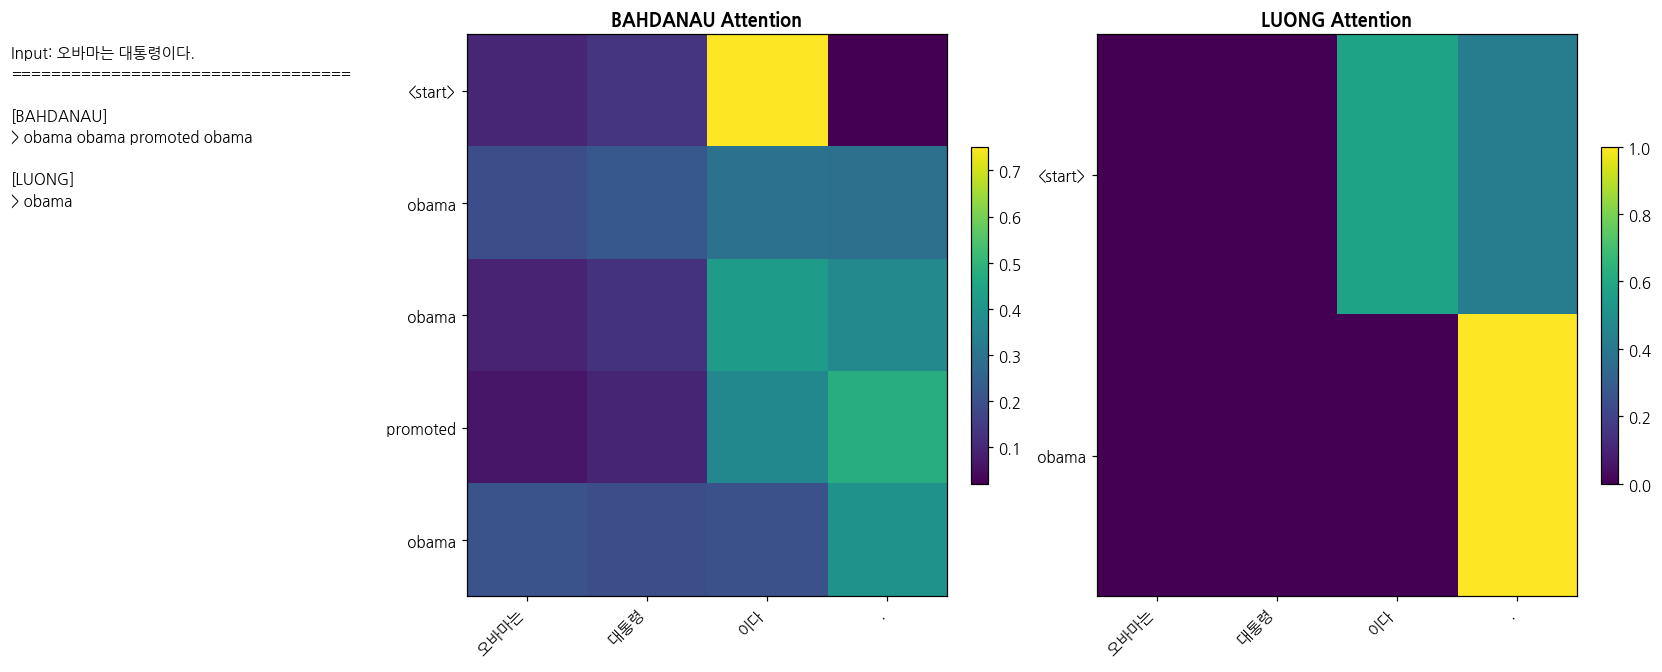

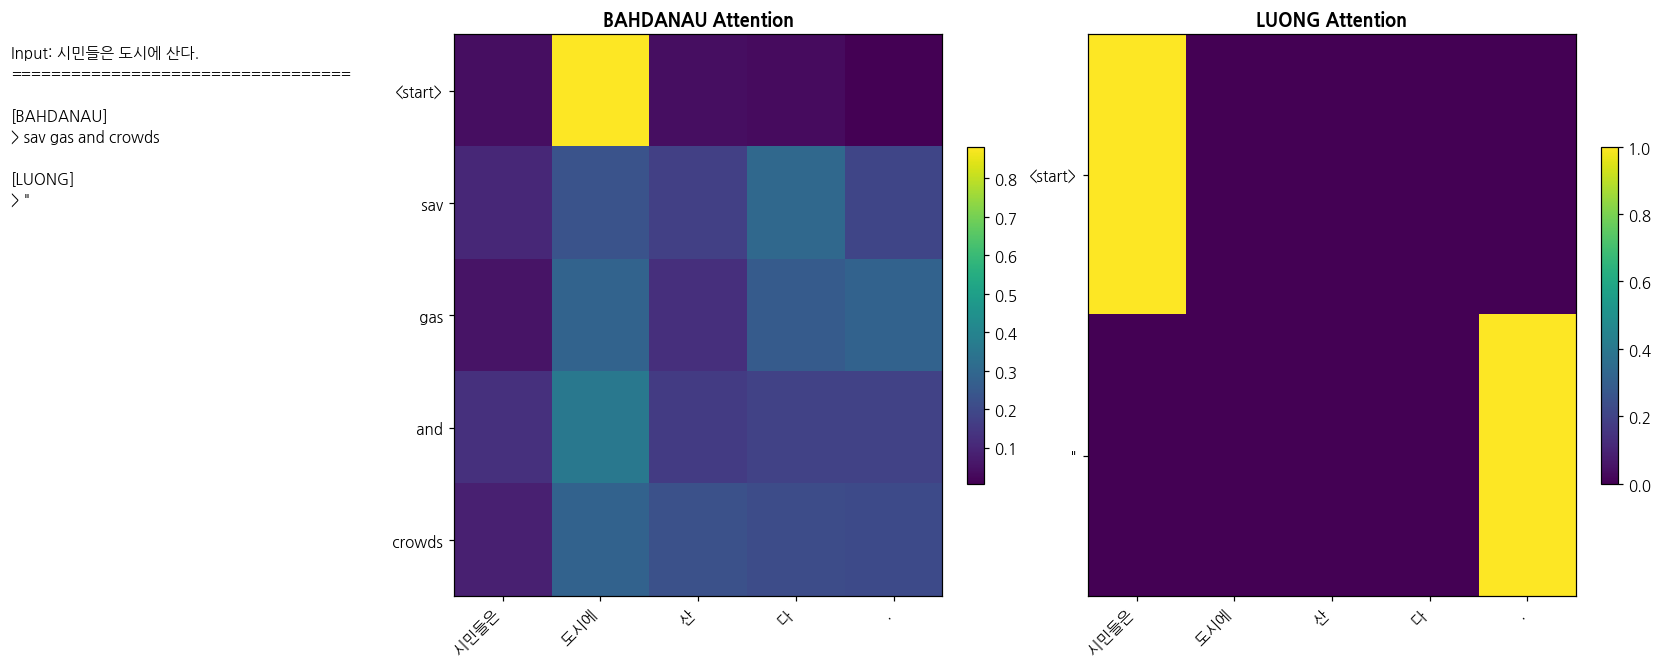

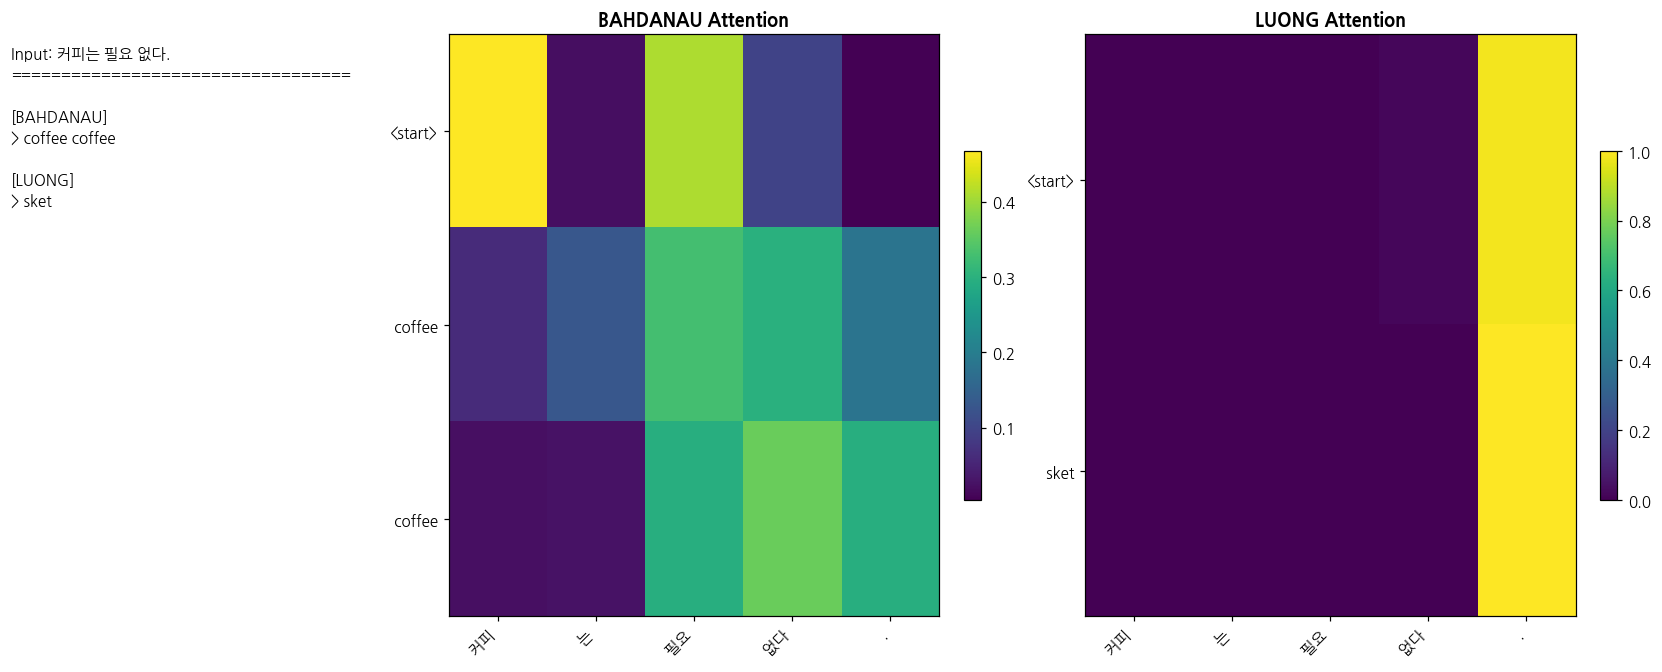

In [72]:
# ============================================================
# [STEP 6-CELL 1] ✅ (우선순위 1) 어텐션 맵 시각화 (Bahdanau vs Luong)
# - 당신이 원하는 비교 방식 유지(안 예뻐도 OK)
# - MIN FIX:
#   1) best 로드 함수/attn 변환/plot 함수 그대로 유지
#   2) 필요한 전역(CKPT_DIR, models, kor_sp, eng_sp, detokenize_eval, greedy_decode, device) 존재만 assert
# ============================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- prerequisites check (MIN FIX: 친절한 에러) ---
need = ["CKPT_DIR", "models", "kor_sp", "eng_sp", "detokenize_eval", "greedy_decode", "device"]
missing = [k for k in need if k not in globals()]
assert not missing, f"[ERROR] Step6-CELL1 prerequisites missing: {missing}"

MAX_DECODE_LEN = 60  # Step4/5와 동일 정책

# -----------------------------
# 0) 폰트 설정
# -----------------------------
def get_font_prop():
    paths = [
        "C:/Windows/Fonts/NanumGothic.ttf",
        "C:/Windows/Fonts/nanumgothic.ttf",
        "C:/Windows/Fonts/malgun.ttf",
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
    ]
    for p in paths:
        if os.path.exists(p):
            return fm.FontProperties(fname=p)
    return None

font_prop = get_font_prop()

def pretty_piece(p: str) -> str:
    return p.replace("▁", " ")

# -----------------------------
# 1) best 체크포인트 로드
# -----------------------------
def load_best_ckpt_to_model(model, name):
    best_path = os.path.join(CKPT_DIR, f"best_{name}.pt")
    assert os.path.isfile(best_path), f"best 체크포인트 없음: {best_path}"

    ckpt = torch.load(best_path, map_location=device)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt

    model.load_state_dict(state)
    model.to(device)
    model.eval()
    return best_path

# -----------------------------
# 2) attn_map → 2D numpy 변환
# -----------------------------
def to_attn_2d(attn_map):

    if attn_map is None:
        return None

    # numpy array
    if isinstance(attn_map, np.ndarray):
        if attn_map.ndim == 2:
            return attn_map
        if attn_map.ndim == 3:
            return attn_map[0]
        return None

    # list / tuple
    if isinstance(attn_map, (list, tuple)):
        mats = []
        for a in attn_map:
            if torch.is_tensor(a):
                a = a.detach().cpu().squeeze()
            else:
                a = torch.tensor(a).detach().cpu().squeeze()
            mats.append(a)
        if len(mats) == 0:
            return None
        M = torch.stack(mats, dim=0)
        return M.numpy()

    # torch tensor
    if torch.is_tensor(attn_map):
        A = attn_map.detach().cpu()
        if A.dim() == 2:
            return A.numpy()
        if A.dim() == 3:
            return A[0].numpy()

    return None

# -----------------------------
# 3) 핵심 비교 시각화
# -----------------------------
def plot_attention_comparison(models_dict, kor_sentence, max_src=25, max_tgt=20):

    fig = plt.figure(figsize=(15, 6), dpi=110, constrained_layout=True)
    gs = fig.add_gridspec(1, 3, width_ratios=[0.9, 1.2, 1.2])

    src_pieces = [pretty_piece(p) for p in kor_sp.EncodeAsPieces(kor_sentence)]
    S = min(len(src_pieces), max_src)
    src_pieces = src_pieces[:S]
    src_ids = kor_sp.EncodeAsIds(kor_sentence)

    info_lines = []
    info_lines.append(f"Input: {kor_sentence}")
    info_lines.append("=" * 34)

    target_models = ["bahdanau", "luong"]

    for idx, name in enumerate(target_models):

        if name not in models_dict:
            continue

        pred_ids, attn_map = greedy_decode(models_dict[name], src_ids, max_len=MAX_DECODE_LEN)

        pred_text = detokenize_eval(eng_sp, pred_ids)
        tgt_pieces = [pretty_piece(eng_sp.IdToPiece(int(t))) for t in pred_ids]

        info_lines.append(f"\n[{name.upper()}]")
        info_lines.append(f"> {pred_text}")

        A = to_attn_2d(attn_map)

        if A is None:
            info_lines.append("(attention map missing)")
            continue

        T = min(len(tgt_pieces), max_tgt, A.shape[0])
        S2 = min(S, A.shape[1])

        A = A[:T, :S2]
        tgt_pieces = tgt_pieces[:T]
        src_show = src_pieces[:S2]

        ax = fig.add_subplot(gs[0, idx + 1])

        im = ax.imshow(A, aspect="auto")

        ax.set_title(f"{name.upper()} Attention", fontsize=12, fontweight="bold")

        ax.set_xticks(range(S2))
        ax.set_xticklabels(src_show, rotation=45, ha="right",
                           fontsize=9, fontproperties=font_prop)

        ax.set_yticks(range(T))
        ax.set_yticklabels(tgt_pieces, fontsize=9, fontproperties=font_prop)

        fig.colorbar(im, ax=ax, shrink=0.6)

    ax_info = fig.add_subplot(gs[0, 0])
    ax_info.axis("off")
    ax_info.text(0, 0.98, "\n".join(info_lines), va="top",
                 fontsize=10, linespacing=1.5, fontproperties=font_prop)

    plt.show()

# -----------------------------
# 4) 실행
# -----------------------------
assert "bahdanau" in models and "luong" in models, "models에 bahdanau/luong이 없습니다."

loaded_models = {
    "bahdanau": models["bahdanau"],
    "luong": models["luong"]
}

for n in ["bahdanau", "luong"]:
    p = load_best_ckpt_to_model(loaded_models[n], n)
    print(f"[OK] loaded best_{n}: {p}")

for s in ["오바마는 대통령이다.", "시민들은 도시에 산다.", "커피는 필요 없다."]:
    plot_attention_comparison(loaded_models, s, max_src=25, max_tgt=20)

models in model_history: ['vanilla', 'bahdanau', 'luong']


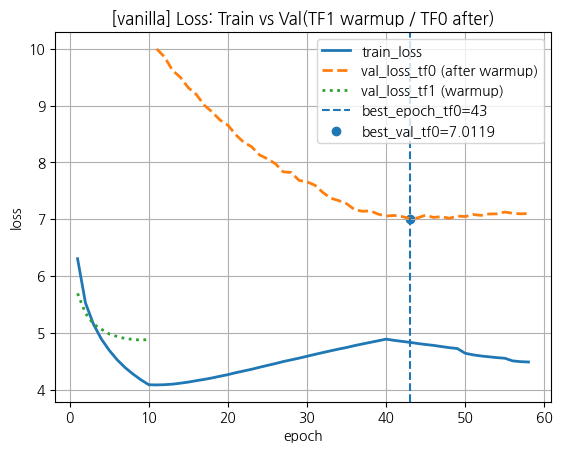

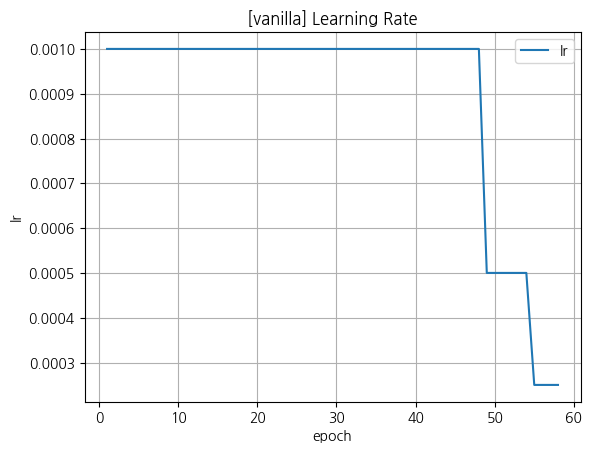

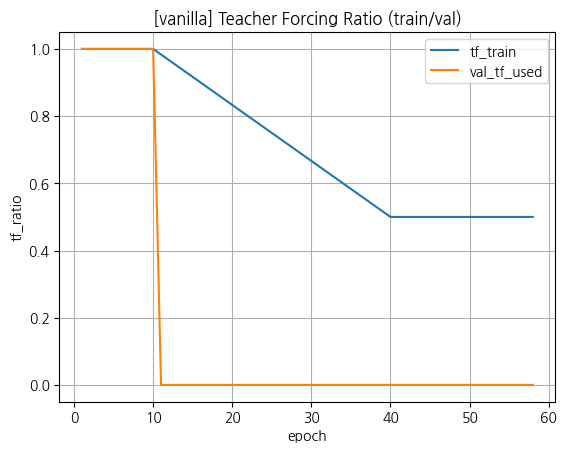

[vanilla] Attention metrics 없음(=vanilla이거나 기록 None).


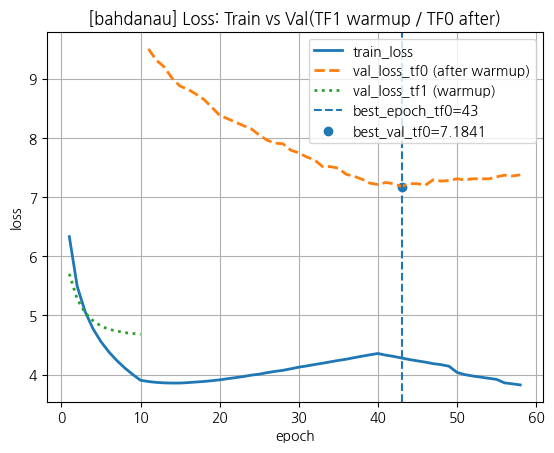

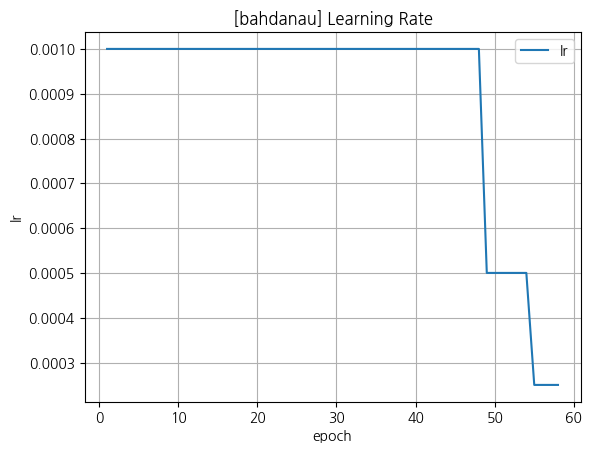

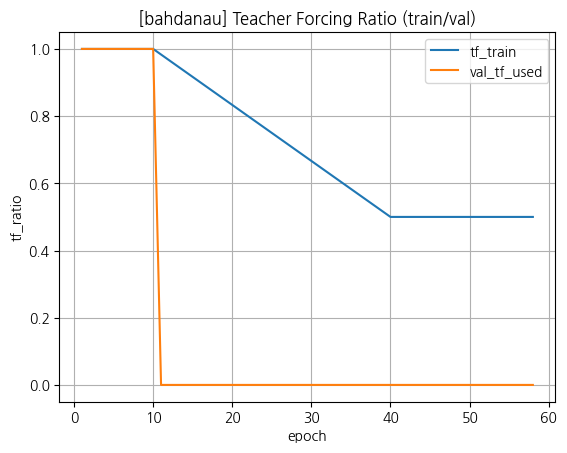

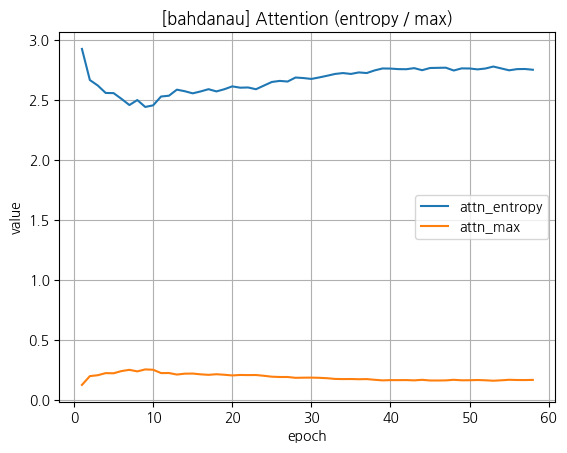

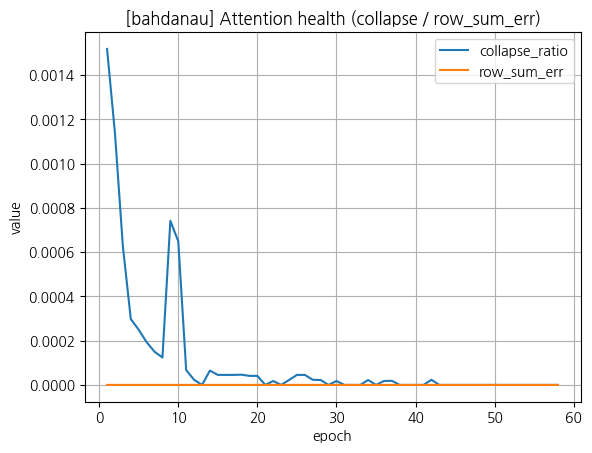

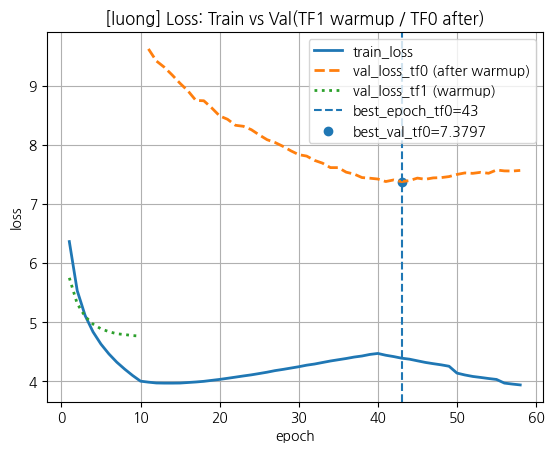

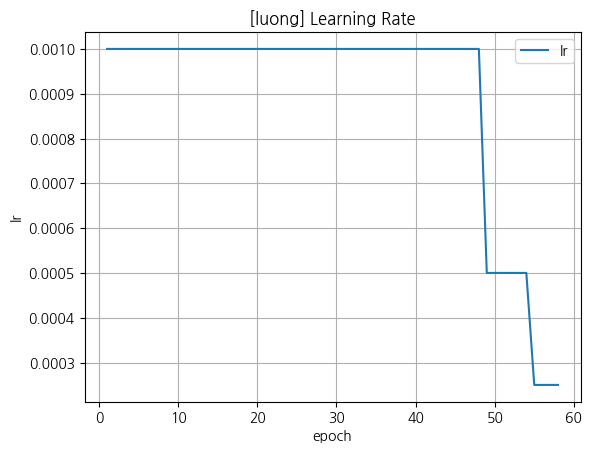

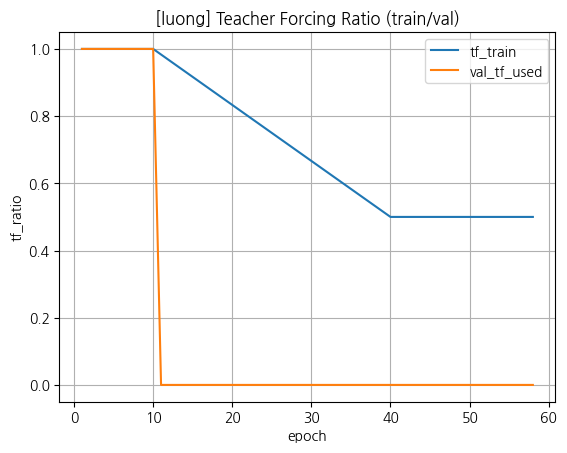

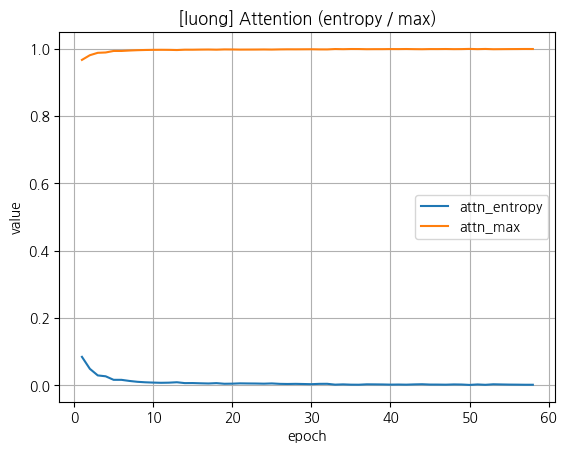

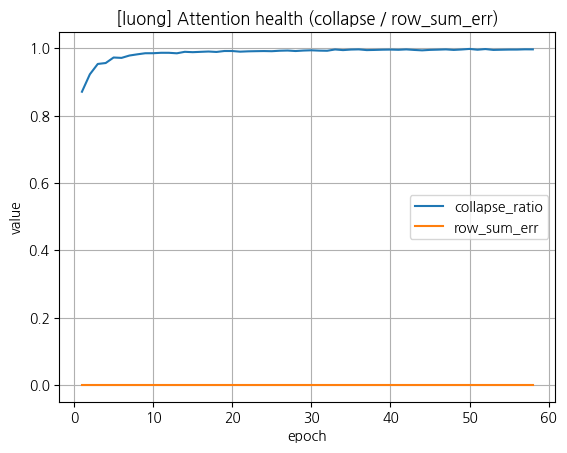

[LEN CHECK] vanilla
 - train_loss len   : 58
 - val_loss_tf0 len : 58
 - val_loss_tf1 len : 58
[LEN CHECK] bahdanau
 - train_loss len   : 58
 - val_loss_tf0 len : 58
 - val_loss_tf1 len : 58
[LEN CHECK] luong
 - train_loss len   : 58
 - val_loss_tf0 len : 58
 - val_loss_tf1 len : 58


In [73]:
# ============================================================
# [STEP 6-CELL 2] ✅ (우선순위 2) 러닝커브/보조지표/어텐션지표 플롯
# - MIN FIX:
#   1) 마지막의 hist NameError 제거 → 모델별 loop로 출력
#   2) None → np.nan 변환 유지 (warmup TF1/TF0 혼합 안정)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# --- prerequisites check ---
assert "model_history" in globals(), "[ERROR] model_history가 없습니다. Step5 학습 루프를 먼저 완료하세요."

def _to_float_nan(seq):
    """None -> np.nan 변환"""
    out = []
    for v in seq:
        out.append(np.nan if v is None else float(v))
    return np.array(out, dtype=float)

def plot_loss_for_one(history, name="run"):
    train = _to_float_nan(history.get("train_loss", []))
    val0  = _to_float_nan(history.get("val_loss_tf0", []))  # warmup엔 nan
    val1  = _to_float_nan(history.get("val_loss_tf1", []))  # warmup엔 값, 이후 nan

    epochs = np.arange(1, len(train) + 1)

    plt.figure()
    plt.plot(epochs, train, label="train_loss", linewidth=2)

    if len(val0) == len(train):
        plt.plot(epochs, val0, label="val_loss_tf0 (after warmup)", linestyle="--", linewidth=2)
    if len(val1) == len(train):
        plt.plot(epochs, val1, label="val_loss_tf1 (warmup)", linestyle=":", linewidth=2)

    best_epoch = history.get("best_epoch_tf0", None)
    best_val   = history.get("best_val_loss_tf0", None)
    if isinstance(best_epoch, int) and best_epoch > 0:
        plt.axvline(best_epoch, linestyle="--", label=f"best_epoch_tf0={best_epoch}")
        if best_val is not None and np.isfinite(best_val):
            plt.scatter([best_epoch], [best_val], marker="o", label=f"best_val_tf0={best_val:.4f}")

    plt.title(f"[{name}] Loss: Train vs Val(TF1 warmup / TF0 after)")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.grid(True); plt.legend()
    plt.show()

def plot_aux_for_one(history, name="run"):
    epochs = np.arange(1, len(history.get("train_loss", [])) + 1)

    lr = _to_float_nan(history.get("lr", []))
    tf_train = _to_float_nan(history.get("tf_train", []))
    val_tf_used = _to_float_nan(history.get("val_tf_used", []))

    if len(lr) == len(epochs):
        plt.figure()
        plt.plot(epochs, lr, label="lr")
        plt.title(f"[{name}] Learning Rate")
        plt.xlabel("epoch"); plt.ylabel("lr")
        plt.grid(True); plt.legend()
        plt.show()

    if len(tf_train) == len(epochs) or len(val_tf_used) == len(epochs):
        plt.figure()
        if len(tf_train) == len(epochs):
            plt.plot(epochs, tf_train, label="tf_train")
        if len(val_tf_used) == len(epochs):
            plt.plot(epochs, val_tf_used, label="val_tf_used")
        plt.title(f"[{name}] Teacher Forcing Ratio (train/val)")
        plt.xlabel("epoch"); plt.ylabel("tf_ratio")
        plt.grid(True); plt.legend()
        plt.show()

def plot_attention_for_one(history, name="run"):
    epochs = np.arange(1, len(history.get("train_loss", [])) + 1)

    ent = _to_float_nan(history.get("attn_entropy", []))
    amax = _to_float_nan(history.get("attn_max", []))
    rowerr = _to_float_nan(history.get("row_sum_err", []))
    collapse = _to_float_nan(history.get("collapse_ratio", []))

    if np.all(np.isnan(ent)) and np.all(np.isnan(amax)) and np.all(np.isnan(collapse)):
        print(f"[{name}] Attention metrics 없음(=vanilla이거나 기록 None).")
        return

    plt.figure()
    if len(ent) == len(epochs):
        plt.plot(epochs, ent, label="attn_entropy")
    if len(amax) == len(epochs):
        plt.plot(epochs, amax, label="attn_max")
    plt.title(f"[{name}] Attention (entropy / max)")
    plt.xlabel("epoch"); plt.ylabel("value")
    plt.grid(True); plt.legend()
    plt.show()

    plt.figure()
    if len(collapse) == len(epochs):
        plt.plot(epochs, collapse, label="collapse_ratio")
    if len(rowerr) == len(epochs):
        plt.plot(epochs, rowerr, label="row_sum_err")
    plt.title(f"[{name}] Attention health (collapse / row_sum_err)")
    plt.xlabel("epoch"); plt.ylabel("value")
    plt.grid(True); plt.legend()
    plt.show()

def plot_all_models(model_history, show_attention=True):
    print("models in model_history:", list(model_history.keys()))
    for name, hist in model_history.items():
        plot_loss_for_one(hist, name=name)
        plot_aux_for_one(hist, name=name)
        if show_attention:
            plot_attention_for_one(hist, name=name)

# ✅ 실행
plot_all_models(model_history, show_attention=True)

# --- MIN FIX: hist NameError 제거 → 모델별로 길이 출력 ---
for name, hist in model_history.items():
    print(f"[LEN CHECK] {name}")
    print(" - train_loss len   :", len(hist.get("train_loss", [])))
    print(" - val_loss_tf0 len :", len(hist.get("val_loss_tf0", [])))
    print(" - val_loss_tf1 len :", len(hist.get("val_loss_tf1", [])))

In [74]:
# ============================================================
# [STEP 6-CELL 3] (그 다음) Step5 BEST 로드 → TEST 최종 1회 평가 (TF=1 Loss + 붕괴지표 + Free-run subset)
# - 당신이 준 Step5-CELL5 코드를 Step6로 가져온 형태(동일 기능)
# - MIN FIX:
#   1) step5_test_results 키를 Step5가 저장한 키(best_epoch_tf0 등)와 정합
# ============================================================

import os
import torch
import torch.nn as nn

need = ["CKPT_DIR","models","test_loader","eng_sp","kor_sp","device",
        "compute_attn_metrics","greedy_decode","detokenize_eval"]
missing = [k for k in need if k not in globals()]
assert not missing, f"[ERROR] Step6-CELL3 prerequisites missing: {missing}"

assert os.path.isdir(CKPT_DIR), f"체크포인트 폴더가 없습니다: {CKPT_DIR}"

criterion_test = nn.CrossEntropyLoss(
    ignore_index=eng_sp.pad_id(),
    label_smoothing=0.0
)

SUBSET_KOR = [
    "오바마는 대통령이다.",
    "시민들은 도시에 산다.",
    "커피는 필요 없다.",
]
MAX_DECODE_LEN = 60

@torch.no_grad()
def eval_test_tf1(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    ent_sum, max_sum, rowerr_sum, coll_sum, attn_batches = 0.0, 0.0, 0.0, 0.0, 0

    for src, src_len, dec_in, dec_out in loader:
        src = src.to(device)
        src_len = src_len.to(device)
        dec_in = dec_in.to(device)
        dec_out = dec_out.to(device)

        logits, attn_all = model(src, src_len, dec_in, teacher_forcing_ratio=1.0)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            dec_out.reshape(-1)
        )
        total_loss += float(loss.item())

        m = compute_attn_metrics(attn_all)
        if m["attn_entropy"] is not None:
            ent_sum += m["attn_entropy"]
            max_sum += m["attn_max"]
            rowerr_sum += m["row_sum_err"]
            coll_sum += m["collapse_ratio"]
            attn_batches += 1

    test_loss = total_loss / max(1, len(loader))

    if attn_batches > 0:
        attn_metrics = {
            "attn_entropy": ent_sum / attn_batches,
            "attn_max": max_sum / attn_batches,
            "row_sum_err": rowerr_sum / attn_batches,
            "collapse_ratio": coll_sum / attn_batches,
        }
    else:
        attn_metrics = {
            "attn_entropy": None,
            "attn_max": None,
            "row_sum_err": None,
            "collapse_ratio": None,
        }

    return test_loss, attn_metrics

@torch.no_grad()
def trackB_free_run_subset(model, subset_kor, max_len=60):
    model.eval()
    end_id = int(eng_sp.PieceToId("<end>"))

    lens = []
    ended = 0
    preds = []

    for s in subset_kor:
        src_ids = kor_sp.EncodeAsIds(s)
        dec_ids, _ = greedy_decode(model, src_ids, max_len=max_len)
        lens.append(len(dec_ids))

        if end_id in dec_ids[1:]:
            ended += 1

        preds.append((s, detokenize_eval(eng_sp, dec_ids)))

    end_rate = ended / max(1, len(subset_kor))
    avg_len = sum(lens) / max(1, len(lens))

    return {
        "end_rate": end_rate,
        "avg_len": avg_len,
        "lens": lens,
        "preds": preds
    }

step5_test_results = {}

for name, model in models.items():

    best_path = os.path.join(CKPT_DIR, f"best_{name}.pt")
    assert os.path.isfile(best_path), f"best 체크포인트가 없습니다: {best_path}"

    ckpt = torch.load(best_path, map_location=device)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    print(f"\n🧪 FINAL TEST (BEST): {name.upper()}")
    print(f" - loaded: {best_path}")

    test_loss_tf1, attn_m = eval_test_tf1(model, test_loader, criterion_test)

    print(f"[Track-A] TEST Loss(tf=1.0): {test_loss_tf1:.4f}")
    if attn_m["attn_entropy"] is not None:
        print(f"         Attn(ent/max/rowerr/collapse): "
              f"{attn_m['attn_entropy']:.3f} / {attn_m['attn_max']:.3f} / {attn_m['row_sum_err']:.3e} / {attn_m['collapse_ratio']:.3f}")
    else:
        print("         Attn metrics: (vanilla) None")

    free_m = trackB_free_run_subset(model, SUBSET_KOR, max_len=MAX_DECODE_LEN)
    print(f"[Track-B] Free-run subset: end_rate={free_m['end_rate']:.2f}, avg_len={free_m['avg_len']:.1f}, lens={free_m['lens']}")
    for src_s, pred_s in free_m["preds"]:
        print(f"   - SRC: {src_s}")
        print(f"     PRED: {pred_s}")

    # ✅ MIN FIX: Step5 history 키와 정합(best_epoch_tf0 / best_val_loss_tf0)
    best_epoch_tf0 = None
    best_val_tf0 = None
    if "model_history" in globals() and name in model_history:
        h = model_history[name]
        best_epoch_tf0 = h.get("best_epoch_tf0", None)
        best_val_tf0   = h.get("best_val_loss_tf0", None)

    step5_test_results[name] = {
        "test_loss_tf1": test_loss_tf1,
        **attn_m,
        "free_end_rate": free_m["end_rate"],
        "free_avg_len": free_m["avg_len"],
        "best_epoch_tf0": best_epoch_tf0,
        "best_val_loss_tf0": best_val_tf0,
    }

print("\n✅ Step6-CELL3 done.")
print("→ step5_test_results 생성 완료")


🧪 FINAL TEST (BEST): VANILLA
 - loaded: ./checkpoints_step5\best_vanilla.pt
[Track-A] TEST Loss(tf=1.0): 4.9530
         Attn metrics: (vanilla) None
[Track-B] Free-run subset: end_rate=1.00, avg_len=6.7, lens=[7, 6, 7]
   - SRC: 오바마는 대통령이다.
     PRED: the the the the the
   - SRC: 시민들은 도시에 산다.
     PRED: the the the the
   - SRC: 커피는 필요 없다.
     PRED: the the's a

🧪 FINAL TEST (BEST): BAHDANAU
 - loaded: ./checkpoints_step5\best_bahdanau.pt
[Track-A] TEST Loss(tf=1.0): 4.8917
         Attn(ent/max/rowerr/collapse): 2.735 / 0.174 / 2.491e-08 / 0.000
[Track-B] Free-run subset: end_rate=1.00, avg_len=5.3, lens=[6, 6, 4]
   - SRC: 오바마는 대통령이다.
     PRED: obama obama promoted obama
   - SRC: 시민들은 도시에 산다.
     PRED: sav gas and crowds
   - SRC: 커피는 필요 없다.
     PRED: coffee coffee

🧪 FINAL TEST (BEST): LUONG
 - loaded: ./checkpoints_step5\best_luong.pt
[Track-A] TEST Loss(tf=1.0): 5.1408
         Attn(ent/max/rowerr/collapse): 0.002 / 0.999 / 5.599e-10 / 0.996
[Track-B] Free-run subset: end_

In [75]:
# ============================================================
# [STEP 6-CELL 4] TEST 전체 디코딩 + detokenize_eval 적용 (캐시)
# - 원본 그대로
# ============================================================

import torch

assert "step5_test_results" in globals(), "step5_test_results가 없습니다. Step6-CELL3를 먼저 실행하세요."

@torch.no_grad()
def greedy_decode_batchwise(model, loader, max_len=60, limit_batches=None):
    model.eval()
    refs = []
    hyps = []

    bcount = 0
    for src, src_len, dec_in, dec_out in loader:
        src = src.to(device)
        src_len = src_len.to(device)
        dec_in = dec_in.to(device)
        dec_out = dec_out.to(device)

        B = src.size(0)
        for i in range(B):
            ref_ids = torch.cat([dec_in[i:i+1, :1], dec_out[i:i+1, :]], dim=1).squeeze(0)
            ref_ids = ref_ids[ref_ids != eng_sp.pad_id()].tolist()
            refs.append(detokenize_eval(eng_sp, ref_ids))

            src_ids = src[i][src[i] != kor_sp.pad_id()].tolist()
            hyp_ids, _ = greedy_decode(model, src_ids, max_len=max_len)
            hyps.append(detokenize_eval(eng_sp, hyp_ids))

        bcount += 1
        if (limit_batches is not None) and (bcount >= limit_batches):
            break

    return refs, hyps

step6_decode_cache = {}

for name, model in models.items():
    best_path = os.path.join(CKPT_DIR, f"best_{name}.pt")
    ckpt = torch.load(best_path, map_location=device)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    print(f"\n[STEP6] Decoding TEST for: {name}")
    refs, hyps = greedy_decode_batchwise(model, test_loader, max_len=MAX_DECODE_LEN, limit_batches=None)
    step6_decode_cache[name] = {"refs": refs, "hyps": hyps}
    print(f" - decoded pairs: {len(refs)}")

print("\n✅ Step6 decode cache ready: step6_decode_cache")


[STEP6] Decoding TEST for: vanilla
 - decoded pairs: 1798

[STEP6] Decoding TEST for: bahdanau
 - decoded pairs: 1798

[STEP6] Decoding TEST for: luong
 - decoded pairs: 1798

✅ Step6 decode cache ready: step6_decode_cache


In [76]:
# ============================================================
# [STEP 6-CELL 5] Corpus BLEU + chrF 계산 + 비교 테이블
# - 원본 그대로(안전 keymap 유지)
# ============================================================

import math
import pandas as pd

def _try_import_sacrebleu():
    try:
        import sacrebleu
        return sacrebleu
    except Exception:
        return None

sacrebleu = _try_import_sacrebleu()

def compute_metrics_bleu_chrf(refs, hyps):
    assert len(refs) == len(hyps), "refs/hyps 길이 불일치"
    if sacrebleu is None:
        return {"bleu": float("nan"), "chrf": float("nan"), "note": "sacrebleu not installed"}
    bleu = sacrebleu.corpus_bleu(hyps, [refs]).score
    chrf = sacrebleu.corpus_chrf(hyps, [refs]).score
    return {"bleu": float(bleu), "chrf": float(chrf), "note": "ok"}

assert isinstance(step5_test_results, dict), "step5_test_results가 dict가 아닙니다."
step5_keymap = {k.lower(): k for k in step5_test_results.keys()}

def get_step5_pack(model_name: str):
    k = step5_keymap.get(model_name.lower(), None)
    return step5_test_results.get(k, {}) if k is not None else {}

rows = []
for name, pack in step6_decode_cache.items():
    refs, hyps = pack["refs"], pack["hyps"]
    m = compute_metrics_bleu_chrf(refs, hyps)
    s5 = get_step5_pack(name)

    rows.append({
        "model": name,
        "BLEU": m["bleu"],
        "chrF": m["chrf"],
        "BLEU_chrF_avg": (m["bleu"] + m["chrf"]) / 2.0
            if (not math.isnan(m["bleu"]) and not math.isnan(m["chrf"]))
            else float("nan"),

        "best_epoch_tf0": s5.get("best_epoch_tf0"),
        "best_val_loss_tf0": s5.get("best_val_loss_tf0"),
        "test_loss_tf1": s5.get("test_loss_tf1"),

        "collapse_ratio": s5.get("collapse_ratio"),
        "attn_max": s5.get("attn_max"),
        "attn_entropy": s5.get("attn_entropy"),

        "note": m["note"],
    })

report_df = pd.DataFrame(rows).sort_values(by=["BLEU_chrF_avg","BLEU","chrF"], ascending=False)
print(report_df)
print("\n✅ Step6 report_df ready (model comparison table).")

      model      BLEU       chrF  BLEU_chrF_avg  best_epoch_tf0  \
1  bahdanau  3.041726  21.744996      12.393361              43   
2     luong  1.918901  17.597266       9.758084              43   
0   vanilla  1.394918  13.675948       7.535433              43   

   best_val_loss_tf0  test_loss_tf1  collapse_ratio  attn_max  attn_entropy  \
1           7.184094       4.891729        0.000000  0.173840      2.735080   
2           7.379676       5.140808        0.995887  0.998948      0.002436   
0           7.011854       4.953035             NaN       NaN           NaN   

  note  
1   ok  
2   ok  
0   ok  

✅ Step6 report_df ready (model comparison table).


In [77]:
# ============================================================
# [STEP 6-CELL 6] 유형별 Subset Analysis (정성)
# - 원본 그대로
# ============================================================

TYPE_SUBSETS = {
    "SHORT": [
        "나는 간다.",
        "그는 왔다.",
        "비가 온다.",
    ],
    "NEG": [
        "커피는 필요 없다.",
        "나는 그것을 원하지 않는다.",
        "그는 오지 못했다.",
    ],
    "NNP": [
        "오바마는 대통령이다.",
        "서울은 한국의 수도이다.",
        "테슬라는 전기차 회사다.",
    ],
}

@torch.no_grad()
def show_subset_outputs(model, subset_dict, max_len=60):
    out = {}
    for typ, sents in subset_dict.items():
        out[typ] = []
        for s in sents:
            pred, _ = sample_translate(model, s, max_len=max_len)
            out[typ].append((s, pred))
    return out

step6_subset_outputs = {}

for name, model in models.items():
    best_path = os.path.join(CKPT_DIR, f"best_{name}.pt")
    ckpt = torch.load(best_path, map_location=device)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    print(f"\n[Subset Analysis] {name.upper()}")
    out = show_subset_outputs(model, TYPE_SUBSETS, max_len=MAX_DECODE_LEN)
    step6_subset_outputs[name] = out

    for typ, pairs in out.items():
        print(f" - TYPE: {typ}")
        for src_s, pred_s in pairs:
            print(f"   SRC : {src_s}")
            print(f"   PRED: {pred_s}")

print("\n✅ Step6 subset outputs cached: step6_subset_outputs")


[Subset Analysis] VANILLA
 - TYPE: SHORT
   SRC : 나는 간다.
   PRED: isanship, the said
   SRC : 그는 왔다.
   PRED: the is a to the
   SRC : 비가 온다.
   PRED: and a day
 - TYPE: NEG
   SRC : 커피는 필요 없다.
   PRED: the the's a
   SRC : 나는 그것을 원하지 않는다.
   PRED: the of the, he said
   SRC : 그는 오지 못했다.
   PRED: the his father, the
 - TYPE: NNP
   SRC : 오바마는 대통령이다.
   PRED: the the the the the
   SRC : 서울은 한국의 수도이다.
   PRED: the the is still in the
   SRC : 테슬라는 전기차 회사다.
   PRED: the the's owner was the

[Subset Analysis] BAHDANAU
 - TYPE: SHORT
   SRC : 나는 간다.
   PRED: i my my
   SRC : 그는 왔다.
   PRED: he was
   SRC : 비가 온다.
   PRED: rain falling down
 - TYPE: NEG
   SRC : 커피는 필요 없다.
   PRED: coffee coffee
   SRC : 나는 그것을 원하지 않는다.
   PRED: i i i
   SRC : 그는 오지 못했다.
   PRED: he's not
 - TYPE: NNP
   SRC : 오바마는 대통령이다.
   PRED: obama obama promoted obama
   SRC : 서울은 한국의 수도이다.
   PRED: the seoul south korea is the seoul south korea
   SRC : 테슬라는 전기차 회사다.
   PRED: electric shibus

[Subset Analysis] LUONG

In [78]:
# ============================================================
# [STEP 6-CELL 7] Luong Attention 붕괴 요약 출력 (보조 로그)
# - MIN FIX: summarize_model 키 정합(best_epoch_tf0 등)
# ============================================================

def summarize_model(name):
    r = step5_test_results.get(name, {})
    row = {
        "model": name,
        "test_loss_tf1": r.get("test_loss_tf1"),
        "best_epoch_tf0": r.get("best_epoch_tf0"),
        "best_val_loss_tf0": r.get("best_val_loss_tf0"),
        "attn_entropy": r.get("attn_entropy"),
        "attn_max": r.get("attn_max"),
        "collapse_ratio": r.get("collapse_ratio"),
        "free_end_rate": r.get("free_end_rate"),
        "free_avg_len": r.get("free_avg_len"),
    }
    return row

target = "luong"
print("[LUONG SUMMARY]")
print(summarize_model(target))

print("\n[LUONG Subset Outputs]")
for typ, pairs in step6_subset_outputs[target].items():
    print(f" - TYPE: {typ}")
    for src_s, pred_s in pairs:
        print(f"   SRC : {src_s}")
        print(f"   PRED: {pred_s}")

print("\n✅ Step6 Luong collapse check complete.")

[LUONG SUMMARY]
{'model': 'luong', 'test_loss_tf1': 5.140808154796732, 'best_epoch_tf0': 43, 'best_val_loss_tf0': 7.379676214853922, 'attn_entropy': 0.0024359075003554482, 'attn_max': 0.9989477724864565, 'collapse_ratio': 0.9958866135827427, 'free_end_rate': 1.0, 'free_avg_len': 3.0}

[LUONG Subset Outputs]
 - TYPE: SHORT
   SRC : 나는 간다.
   PRED: loya
   SRC : 그는 왔다.
   PRED: indef
   SRC : 비가 온다.
   PRED: independ
 - TYPE: NEG
   SRC : 커피는 필요 없다.
   PRED: sket
   SRC : 나는 그것을 원하지 않는다.
   PRED: pil tone
   SRC : 그는 오지 못했다.
   PRED: pakistanis
 - TYPE: NNP
   SRC : 오바마는 대통령이다.
   PRED: obama
   SRC : 서울은 한국의 수도이다.
   PRED: seoul seoul seoul
   SRC : 테슬라는 전기차 회사다.
   PRED: hopped the

✅ Step6 Luong collapse check complete.
